In [1]:
!nvidia-smi


Mon Aug 31 10:23:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 2.2.3


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve dataset path: works both locally (repo root) and in Colab
# (upload the CSV to /content/ in Colab, or place it in data/ locally)
DATA_PATH = next(
    p for p in [
        Path("data/risk_factors_cervical_cancer.csv"),
        Path("/content/risk_factors_cervical_cancer.csv"),
    ]
    if p.exists()
)

df = pd.read_csv(DATA_PATH, na_values="?")

df.head()


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [6]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.000000,845.000000,845.000000,750.000000,750.000000,741.000000,...,71.000000,71.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.453144,0.641333,2.256419,0.112011,...,6.140845,5.816901,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,2.226610,0.479929,3.764254,0.315593,...,5.895024,5.755271,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,...,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,8.000000,7.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(23)

In [8]:
df.nunique()

,0
Age,44
Number of sexual partners,12
First sexual intercourse,21
Num of pregnancies,11
Smokes,2
Smokes (years),30
Smokes (packs/year),62
Hormonal Contraceptives,2
Hormonal Contraceptives (years),40
IUD,2


In [9]:
df["Biopsy"].value_counts()

,count
Biopsy,
0,803
1,55


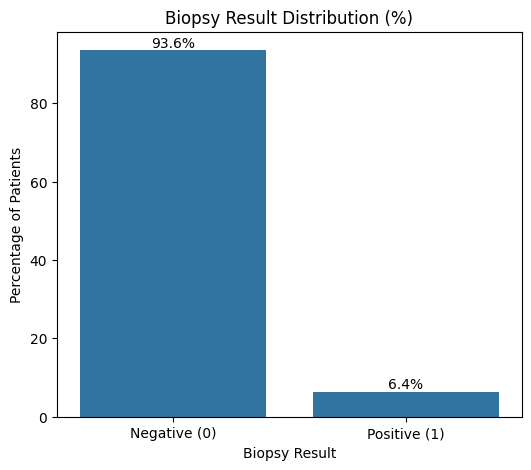

In [10]:
biopsy_percent = df["Biopsy"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    x=["Negative (0)", "Positive (1)"],
    y=biopsy_percent.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Biopsy Result Distribution (%)")
plt.xlabel("Biopsy Result")
plt.ylabel("Percentage of Patients")

plt.show()

The biopsy results are highly imbalanced, with 93.6% of patients having a negative biopsy and only 6.4% having a positive biopsy. This means the model has far fewer positive cases to learn from. As a result accuracy alone may be misleading—a model could achieve high accuracy simply by predicting most patients as negative. Therefore, metrics such as precision, recall, F1-score, ROC-AUC, and especially recall for the positive class should also be considered.

In [11]:
df["Age"].describe()


,Age
count,858.000000
mean,26.820513
std,8.497948
min,13.000000
25%,20.000000
50%,25.000000
75%,32.000000
max,84.000000


In [12]:
df["First sexual intercourse"].describe()

,First sexual intercourse
count,851.000000
mean,16.995300
std,2.803355
min,10.000000
25%,15.000000
50%,17.000000
75%,18.000000
max,32.000000


In [13]:
df["First sexual intercourse"] = pd.to_numeric(
    df["First sexual intercourse"],
    errors="coerce"
)

df["First sexual intercourse"].describe()

,First sexual intercourse
count,851.000000
mean,16.995300
std,2.803355
min,10.000000
25%,15.000000
50%,17.000000
75%,18.000000
max,32.000000


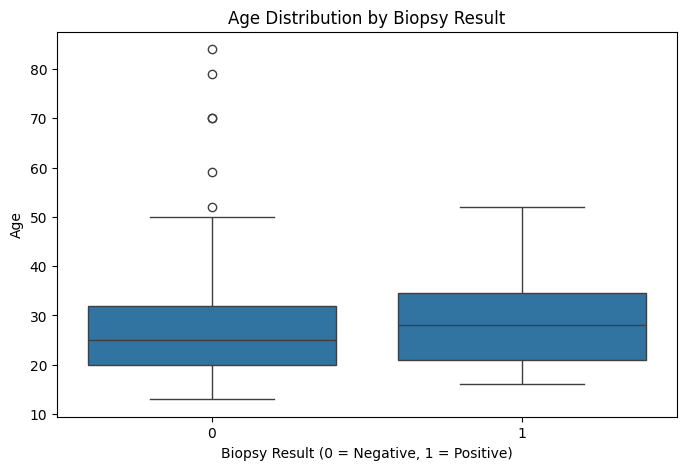

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Biopsy", y="Age")

plt.title("Age Distribution by Biopsy Result")
plt.xlabel("Biopsy Result (0 = Negative, 1 = Positive)")
plt.ylabel("Age")

plt.show()

In [15]:
imp_features = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes",
    "Smokes (years)",
    "Hormonal Contraceptives",
    "Hormonal Contraceptives (years)",
    "IUD",
    "IUD (years)",
    "STDs",
    "STDs (number)",
    "STDs:HPV",
    "STDs:HIV",
    "Dx:Cancer",
    "Dx:CIN",
    "Dx:HPV",
    "Hinselmann",
    "Schiller",
    "Citology",
    "Biopsy"
]

corr_df = df[imp_features].apply(pd.to_numeric, errors="coerce")

biopsy_correlation = corr_df.corr()["Biopsy"].drop("Biopsy")

biopsy_correlation = biopsy_correlation.sort_values(ascending=False)

biopsy_correlation

,Biopsy
Schiller,0.733204
Hinselmann,0.547417
Citology,0.327466
Dx:Cancer,0.160905
Dx:HPV,0.160905
STDs:HIV,0.126880
Dx:CIN,0.113172
STDs,0.109099
STDs (number),0.098347
Hormonal Contraceptives (years),0.079388


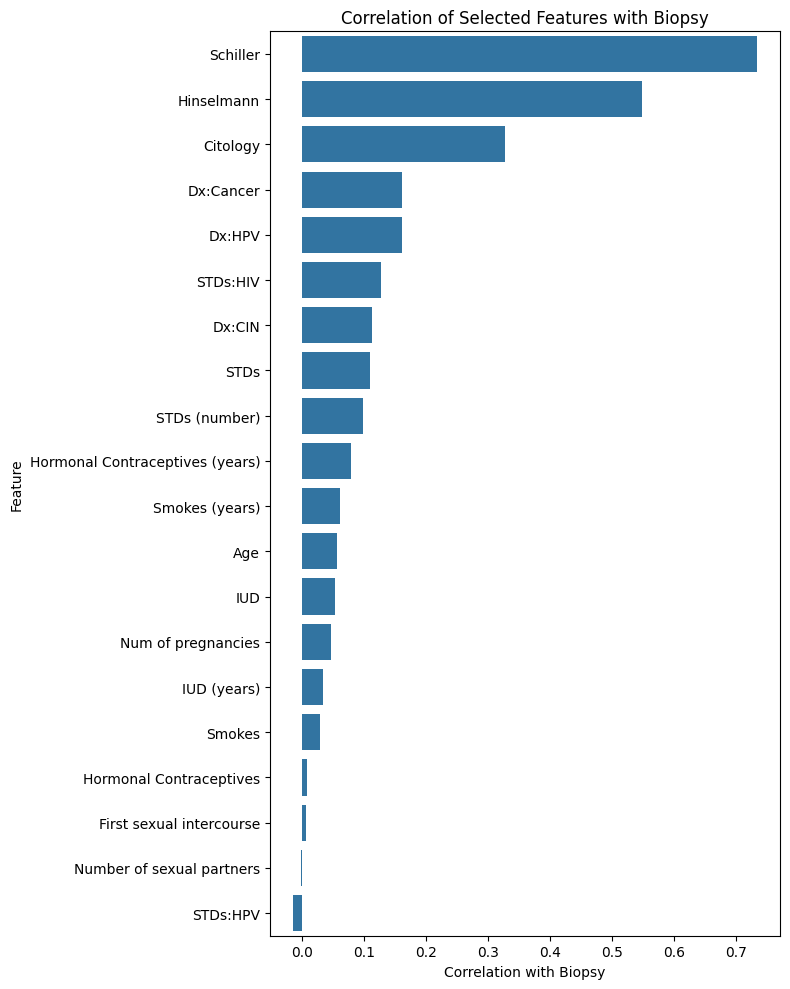

In [16]:
plt.figure(figsize=(8, 10))

sns.barplot(
    x=biopsy_correlation.values,
    y=biopsy_correlation.index
)

plt.title("Correlation of Selected Features with Biopsy")
plt.xlabel("Correlation with Biopsy")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The correlation results make sense from a medical perspective. The strongest relationships with biopsy are seen for **Schiller, Hinselmann, and Cytology**, which are all methods used to identify abnormal changes in the cervix, so it is reasonable that they are strongly associated with biopsy results. The group of diagnosis-related variables—**Dx:Cancer, Dx:HPV, and Dx:CIN**—also shows relatively strong correlations because they are directly related to cervical disease, with Dx meaning “diagnosis.” HIV and other STDs can also be associated with cervical abnormalities, especially because a weakened immune system can make it harder to clear HPV. Variables such as smoking, hormonal contraceptive use, age, and IUD use have weaker relationships, which is also reasonable because they are more indirect risk factors rather than direct measures of cervical abnormalities. However, the strong correlation of the screening and diagnosis-related variables is something to be careful about. If the goal is to predict cervical cancer risk before diagnosis, using variables such as Schiller, Hinselmann, Cytology, Dx:Cancer, and Dx:CIN could introduce data leakage because these variables may already contain information obtained during the diagnostic process. Therefore, the timing and purpose of each variable should be considered before using them as predictors.


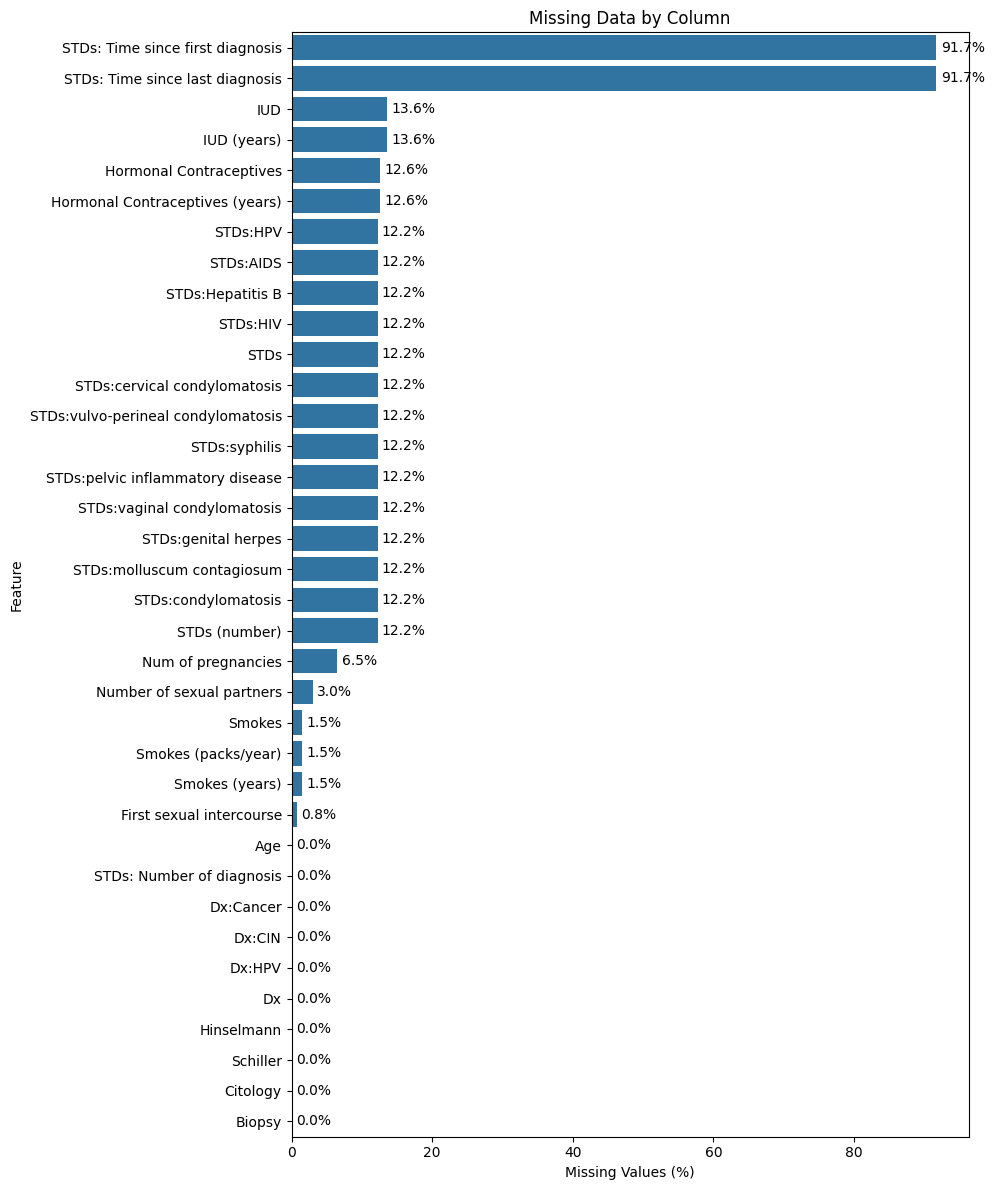

In [17]:
missing_count = df.isna().sum()

missing_percent = (missing_count / len(df)) * 100

missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10, 12))

ax = sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Missing Data by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

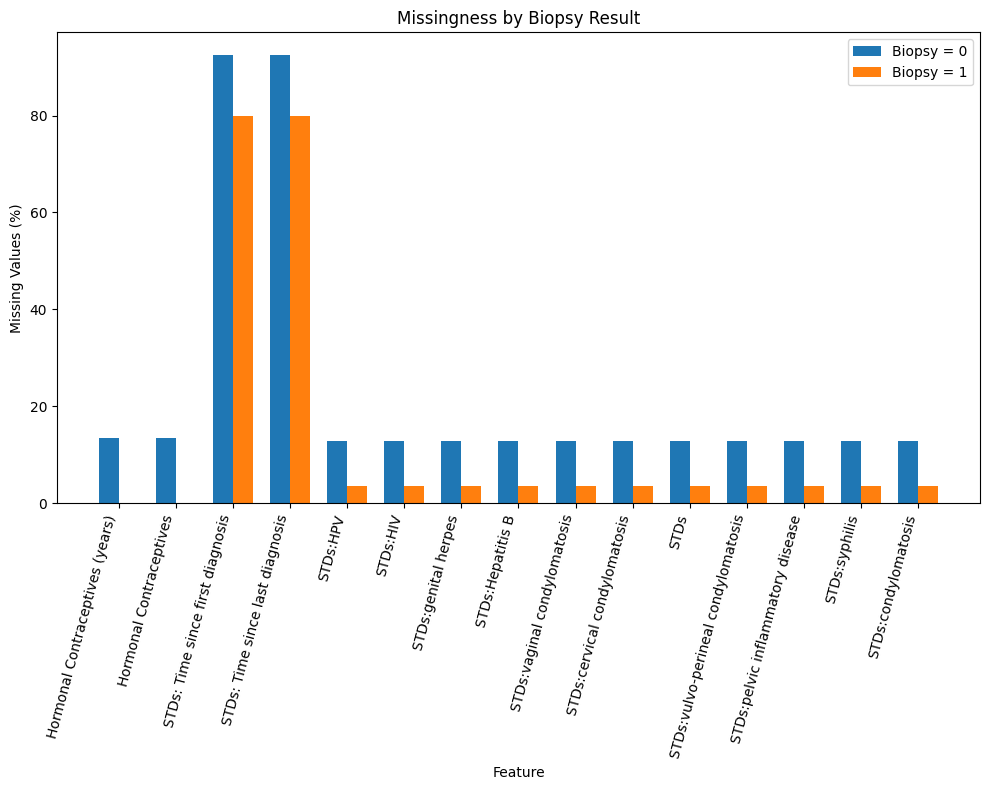

In [18]:

missing_by_biopsy = {}
for col in df.columns:
    missing_by_biopsy[col] = {
        "Biopsy 0 (%)": df.loc[df["Biopsy"] == 0, col].isna().mean() * 100,
        "Biopsy 1 (%)": df.loc[df["Biopsy"] == 1, col].isna().mean() * 100
    }

missing_by_biopsy = pd.DataFrame(missing_by_biopsy).T
missing_by_biopsy["diff"] = (missing_by_biopsy["Biopsy 1 (%)"]
                             - missing_by_biopsy["Biopsy 0 (%)"])
missing_by_biopsy.sort_values("diff", key=abs, ascending=False)

missing_by_biopsy

missing_by_biopsy["Difference (%)"] = (
    missing_by_biopsy["Biopsy 1 (%)"] -
    missing_by_biopsy["Biopsy 0 (%)"]
)

missing_by_biopsy.sort_values(
    "Difference (%)",
    ascending=False
)

top_missing = (
    missing_by_biopsy
    .sort_values("Difference (%)", key=abs, ascending=False)
    .head(15)
)

top_missing


plt.figure(figsize=(10, 8))

x = np.arange(len(top_missing))
width = 0.35

plt.bar(
    x - width/2,
    top_missing["Biopsy 0 (%)"],
    width,
    label="Biopsy = 0"
)

plt.bar(
    x + width/2,
    top_missing["Biopsy 1 (%)"],
    width,
    label="Biopsy = 1"
)

plt.xticks(
    x,
    top_missing.index,
    rotation=75,
    ha="right"
)

plt.ylabel("Missing Values (%)")
plt.xlabel("Feature")
plt.title("Missingness by Biopsy Result")
plt.legend()

plt.tight_layout()
plt.show()

The missingness analysis showed clear differences between the biopsy-negative and biopsy-positive groups. Several STD-related variables had particularly high levels of missing data, and the proportion of missing values was consistently different between the two groups. Based on this analysis, it most probably means that the missingness itself is related to the target rather than being completely random. The observed differences are clear in the data, so this is something we need to keep in mind when reproducing the preprocessing and handling the missing values.


# Raw Data Analysis — Summary

The raw dataset was explored first without applying any preprocessing or modifying the original values.

### 1. Dataset Structure

Loaded the original dataset and inspected the first few records, dataset dimensions, data types, and overall structure. The dataset contains **858 observations and 36 features**.

### 2. Basic Statistical Analysis

Used `info()` and `describe()` to examine the available data types, ranges, distributions, and basic statistics of the numerical variables. The `Age` feature ranges from **13 to 84 years**, with a mean of approximately **26.8 years**.

### 3. Feature & Value Inspection

Checked the number of unique values in each feature and inspected how categorical and binary variables are represented. Most of the clinical/detection variables are binary, while variables such as age, number of sexual partners, smoking duration, and other measurements contain multiple values.

### 4. Duplicate Analysis

Checked the raw dataset for duplicate observations and found **23 duplicate rows**. These were identified but not removed at this stage, since the raw dataset is being preserved for reproducibility.

### 5. Target Variable — Biopsy

Analyzed `Biopsy` as the target variable, where `0` represents a negative result and `1` represents a positive result. The dataset contains **803 negative cases (93.6%) and 55 positive cases (6.4%)**, showing a strong class imbalance.

Because of this imbalance, accuracy alone may not provide a reliable picture of model performance. Metrics such as precision, recall, F1-score and ROC-AUC will therefore be important during model evaluation.

### 6. Missing Data

The raw dataset uses `?` to represent missing values rather than standard `NaN` values. Missing values were counted for every feature and their percentages were visualized to understand the overall missing-data pattern.

Several features, particularly those related to STDs, contain substantial amounts of missing data.

### 7. Missingness vs. Biopsy

Missing-data patterns were compared between the biopsy-negative and biopsy-positive groups. Several features showed noticeable differences in their missingness rates between the two groups.

This suggests that the missingness itself is **most probably related to the target rather than being completely random**. This is an important observation because the way these `?` values are handled during preprocessing could potentially influence the resulting model.

### 8. Feature–Target Relationship

Calculated correlations between selected important features and the `Biopsy` target to obtain an initial understanding of their association with the outcome.

These correlations are treated only as exploratory observations at this stage and are **not being used for feature selection**.

### Overall Observation

The raw dataset has now been characterized in terms of its structure, feature representation, duplicates, target distribution, missing-data patterns, and initial feature–target relationships.

**No imputation, feature removal, scaling, encoding, or other preprocessing has been performed yet.**

The next step is to examine the original paper's **Pre-processing** section and reproduce its methodology step-by-step.



In [19]:
#copy of the original raw dataset
df_raw = df.copy()

# dataframe to be used for preprocessing
df = df_raw.copy()

print("Remaining '?' values:", (df == "?").sum().sum())
print("Total NaN values:", df.isna().sum().sum())

df_raw.head()

Remaining '?' values: 0
Total NaN values: 3622


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


# **Data Pre-processing**

In [20]:
y = df["Biopsy"].copy()

df = df.drop(columns=["Hinselmann", "Schiller", "Citology", "Biopsy"])

df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0


### Rule 1 — Median Imputation

The paper states that features with fewer than 100 missing (`NaN`) values should have those values replaced with the feature's median.

The dataset was checked for missing-value counts, and this rule was applied to all applicable features. The relevant columns were converted to numeric format before calculating their medians.



In [21]:
# columns with fewer than 100 missing values
missing_counts = df.isna().sum()

low_missing_cols = missing_counts[
    (missing_counts > 0) & (missing_counts < 100)
].index

# fill missing values with the median
for col in low_missing_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# test
df[low_missing_cols].isna().sum()

,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0


### Rule 2 — Verify Relevant Attributes

The paper states that `Age` and `Num of pregnancies` influence `Hormonal Contraceptives`. We first verify this relationship using Pearson correlation before applying the missing-value rule described by the authors.

In [22]:
hc_corr = df[
    ["Hormonal Contraceptives", "Age", "Num of pregnancies"]
].corr(method="pearson")

hc_corr

,Hormonal Contraceptives,Age,Num of pregnancies
Hormonal Contraceptives,1.000000,0.068607,0.151498
Age,0.068607,1.000000,0.525892
Num of pregnancies,0.151498,0.525892,1.000000


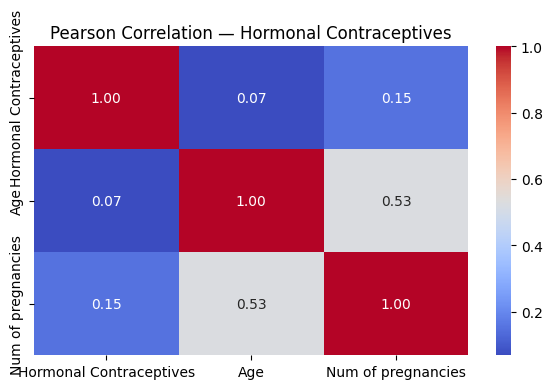

In [23]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    hc_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Pearson Correlation — Hormonal Contraceptives")
plt.tight_layout()
plt.show()

### Observation

The Pearson correlations between Hormonal Contraceptives and the two attributes were relatively weak in our reproduction (Age: r = 0.069; Number of pregnancies: r = 0.151).

This indicates that the linear associations observed in this dataset are limited. However, the use of Age and Number of pregnancies as related factors may still have a reasonable domain-based interpretation, as contraceptive use can be influenced by factors such as age and reproductive history.



### Rule 2 - Hormonal Contraceptives Imputation

Following the methodology described in the paper, Pearson correlation was calculated between `Hormonal Contraceptives`, `Age`, and `Num of pregnancies`.

The paper identifies Age and Number of pregnancies as relevant attributes for determining missing Hormonal Contraceptives values. Based on the rule described by the authors, missing values were subsequently inferred using the condition:

- Age > mean Age, OR
- Number of pregnancies < mean Number of pregnancies

This rule was implemented as described in the paper.

In [24]:
age_mean = df["Age"].mean()
preg_mean = df["Num of pregnancies"].mean()

mask = df["Hormonal Contraceptives"].isna()

df.loc[mask, "Hormonal Contraceptives"] = (
    (df.loc[mask, "Age"] > age_mean) |
    (df.loc[mask, "Num of pregnancies"] < preg_mean)
).astype(int)

Deal with Hormonal Contraceptives (years)

In [25]:
df.groupby("Hormonal Contraceptives")[
    "Hormonal Contraceptives (years)"
].median()

,Hormonal Contraceptives (years)
Hormonal Contraceptives,
0.0,0.0
1.0,2.0


In [26]:
obs = df[df['IUD'].notna()]
age_mean  = df['Age'].mean()
preg_mean = df['Num of pregnancies'].mean()

p80 = (obs.loc[obs['IUD']==1, 'Age'] > age_mean).mean()
p70 = (obs.loc[obs['IUD']==0, 'Num of pregnancies'] < preg_mean).mean()

print(f"claimed 80% -> measured {p80:.1%}")
print(f"claimed 70% -> measured {p70:.1%}")

claimed 80% -> measured 79.5%
claimed 70% -> measured 69.6%


# Observation — IUD Relationships Verification Rule 3
The paper reports that 80% of patients taking an IUD are older than the average age, while 70% of patients who do not take an IUD have fewer pregnancies than the mean. These claims were independently checked during the reproduction and produced very similar results: 79.5% and 69.6%, respectively.

In [27]:
#  Hormonal Contraceptives group
hc_years_medians = df.groupby(
    "Hormonal Contraceptives"
)["Hormonal Contraceptives (years)"].median()

print(hc_years_medians)
# Missing HC (years) values
mask = df["Hormonal Contraceptives (years)"].isna()

# Fill
df.loc[mask, "Hormonal Contraceptives (years)"] = (
    df.loc[mask, "Hormonal Contraceptives"]
    .map(hc_years_medians)
)

print(
    "Remaining HC (years) NaN values:",
    df["Hormonal Contraceptives (years)"].isna().sum()
)

Hormonal Contraceptives
0.0    0.0
1.0    2.0
Name: Hormonal Contraceptives (years), dtype: float64
Remaining HC (years) NaN values: 0


In [28]:
# Use only rows where IUD is already known
observed = df["IUD"].notna()

actual = df.loc[observed, "IUD"].astype(int)

# Candidate conditions based on the relationships described in the paper
age = df.loc[observed, "Age"] > age_mean
preg = df.loc[observed, "Num of pregnancies"] < preg_mean

rules = {
    "A (AND)": (age & preg).astype(int),
    "B (OR)": (age | preg).astype(int),
    "C (Cascade)": np.where(~age, 0, (~preg).astype(int))
}

# Compare each candidate rule with the actual observed IUD values
for name, prediction in rules.items():
    prediction = pd.Series(prediction, index=actual.index)

    accuracy = (prediction == actual).mean()

    print(f"{name:12s} Accuracy: {accuracy:.2%}")

A (AND)      Accuracy: 73.28%
B (OR)       Accuracy: 17.68%
C (Cascade)  Accuracy: 74.90%


### Observation — Candidate IUD Rules

The paper identifies Age and Number of pregnancies as the main attributes associated with IUD status but does not provide an explicit Boolean rule for inferring missing IUD values.

To investigate the most plausible interpretation, several candidate rules were compared against observations where IUD status was already known. The AND rule reproduced 73.28% of the observed values, while the cascade rule reproduced 74.90%. The OR rule performed substantially worse at 17.68%.

The results suggest that the OR interpretation is unlikely to represent the relationship described by the authors. The cascade rule showed the highest agreement among the tested interpretations, although its improvement over the AND rule was small. Therefore, this analysis helps identify a plausible implementation, but it cannot establish the exact rule used in the original study.

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

for name, prediction in rules.items():
    prediction = pd.Series(prediction, index=actual.index).astype(int)

    print(f"\n{name}")
    print(confusion_matrix(actual, prediction))
    print(classification_report(actual, prediction, zero_division=0))


A (AND)
[[518 140]
 [ 58  25]]
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       658
           1       0.15      0.30      0.20        83

    accuracy                           0.73       741
   macro avg       0.53      0.54      0.52       741
weighted avg       0.82      0.73      0.77       741


B (OR)
[[ 56 602]
 [  8  75]]
              precision    recall  f1-score   support

           0       0.88      0.09      0.16       658
           1       0.11      0.90      0.20        83

    accuracy                           0.18       741
   macro avg       0.49      0.49      0.18       741
weighted avg       0.79      0.18      0.16       741


C (Cascade)
[[514 144]
 [ 42  41]]
              precision    recall  f1-score   support

           0       0.92      0.78      0.85       658
           1       0.22      0.49      0.31        83

    accuracy                           0.75       741
   macro avg       0.57      

The cascade rule also provided the strongest recall and F1-score for the positive IUD class among the tested approaches (49% recall, F1 = 0.31). Therefore, among the candidate interpretations tested, the cascade rule provides the closest match to the observed data. This should be considered an inferred reproduction of the paper's description rather than a confirmed reconstruction of the original implementation.

# Rule 3 — Fill missing IUD values using selected cascade rule

Cascade rule:

Age <= mean  → IUD = 0

Age > mean   → use pregnancy condition

In [30]:

mask = df["IUD"].isna()

age = df.loc[mask, "Age"] > age_mean
preg = df.loc[mask, "Num of pregnancies"] < preg_mean


df.loc[mask, "IUD"] = np.where(
    ~age,
    0,
    (~preg).astype(int)
)
#tests

print("Remaining IUD NaN values:", df["IUD"].isna().sum())


print("\nIUD distribution after imputation:")
print(df["IUD"].value_counts())

Remaining IUD NaN values: 0

IUD distribution after imputation:
IUD
0.0    757
1.0    101
Name: count, dtype: int64


# Rule 3b — IUD (Years) Imputation

The paper states that if a patient takes an IUD, IUD (years) should be non-zero, and missing/invalid duration values should be adjusted using mean values.

In [31]:
# Mean
iud_years_mean = df.loc[
    df["IUD"] == 1,
    "IUD (years)"
].mean()

print("Mean IUD duration:", iud_years_mean)

# Fill missing IUD (years)
mask = df["IUD (years)"].isna()

df.loc[mask, "IUD (years)"] = np.where(
    df.loc[mask, "IUD"] == 1,
    iud_years_mean,
    0
)

#test

print(
    "Remaining IUD (years) NaN:",
    df["IUD (years)"].isna().sum()
)

Mean IUD duration: 4.596024096385542
Remaining IUD (years) NaN: 0


### Rule 4 — Verify the Proposed STD Imputation Inputs

The paper proposes using `STDs:condylomatosis` and `STDs:vulvo-perineal condylomatosis` to infer missing values in the `STDs` variable.

To verify whether this rule can be reproduced on the dataset, we check:
1. The number of missing values in all three variables.
2. Whether the missing values occur in the same records.
3. Whether the two supporting variables are actually available for the observations where `STDs` is missing.

This determines whether the variables identified by the paper can genuinely be used to perform the proposed imputation.

In [32]:
rule4_cols = [
    "STDs",
    "STDs:condylomatosis",
    "STDs:vulvo-perineal condylomatosis"
]

missing_masks = df[rule4_cols].isna()

# Missing count
print("Missing values:")
print(missing_masks.sum())

# same missing rows?
same_missing_pattern = (
    missing_masks["STDs"] ==
    missing_masks["STDs:condylomatosis"]
).all() and (
    missing_masks["STDs"] ==
    missing_masks["STDs:vulvo-perineal condylomatosis"]
).all()

print("\nSame missing rows across all three columns:", same_missing_pattern)

Missing values:
STDs                                  105
STDs:condylomatosis                   105
STDs:vulvo-perineal condylomatosis    105
dtype: int64

Same missing rows across all three columns: True


In [33]:
st_missing = set(df.index[df["STDs"].isna()])
cond_missing = set(df.index[df["STDs:condylomatosis"].isna()])
vulvo_missing = set(
    df.index[df["STDs:vulvo-perineal condylomatosis"].isna()]
)

print("STDs == Condylomatosis:", st_missing == cond_missing)
print("STDs == Vulvo-perineal:", st_missing == vulvo_missing)
print(
    "All three identical:",
    st_missing == cond_missing == vulvo_missing
)

STDs == Condylomatosis: True
STDs == Vulvo-perineal: True
All three identical: True


### Observation — Rule 4 Missingness Pattern

The missing-value pattern was verified for the three variables involved in Rule 4:
`STDs`, `STDs:condylomatosis`, and `STDs:vulvo-perineal condylomatosis`.

All three variables contain 105 missing values, and the missing records are identical across all three columns.

Therefore, for these 105 observations, the two STD-specific variables proposed by the paper for inferring `STDs` are themselves missing. This means the Rule 4 imputation cannot be directly reproduced for these records from the methodology provided in the paper.

No additional imputation rule is introduced at this stage; the limitation is documented as part of the reproducibility analysis.

In [34]:
std_disease_cols = [
    'STDs:condylomatosis',
    'STDs:cervical condylomatosis',
    'STDs:vaginal condylomatosis',
    'STDs:vulvo-perineal condylomatosis',
    'STDs:syphilis',
    'STDs:pelvic inflammatory disease',
    'STDs:genital herpes',
    'STDs:molluscum contagiosum',
]

# Check the median that Rule 5 would use
for c in std_disease_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(
    df[std_disease_cols]
    .median()
    .sort_values()
)


m = df['STDs (number)'].isna()
print("missing:", m.sum(), "| their STDs:", df.loc[m,'STDs'].value_counts().to_dict())

df.loc[m & (df['STDs'] == 0), 'STDs (number)'] = 0

r = df['STDs (number)'].isna()
if r.any():
    print("residual:", r.sum(), "| STDs:", df.loc[r,'STDs'].unique())
    df.loc[r, 'STDs (number)'] = df.loc[r, 'STDs: Number of diagnosis']

assert df['STDs (number)'].isna().sum() == 0

STDs:condylomatosis                   0.0
STDs:cervical condylomatosis          0.0
STDs:vaginal condylomatosis           0.0
STDs:vulvo-perineal condylomatosis    0.0
STDs:syphilis                         0.0
STDs:pelvic inflammatory disease      0.0
STDs:genital herpes                   0.0
STDs:molluscum contagiosum            0.0
dtype: float64
missing: 105 | their STDs: {}
residual: 105 | STDs: [nan]


### Rules 5 → 4 — STD Missing-Value Handling

The paper states that individual STD-disease attributes can be filled using median values, while `STDs` can be inferred from `STDs:condylomatosis` and `STDs:vulvo-perineal condylomatosis`.

Because these three variables have identical missing-value patterns in the raw dataset, Rule 4 cannot be applied directly before filling the STD-disease variables. Therefore, Rule 5 was applied first as an inferred processing order: missing values in the selected STD-disease attributes were replaced with their respective medians.

After this step, the two STD-specific attributes could be used to infer the missing `STDs` values according to Rule 4:
- If either STD condition was present → `STDs = 1`
- If neither condition was present → `STDs = 0`

All missing `STDs` values were successfully filled. The resulting full-column STD-positive rate was approximately **9.21%**, equal to the observed rate after imputation.

In [35]:
# Rule 5 — median imputation for selected STD-disease variables
for c in std_disease_cols:
    df[c] = df[c].fillna(df[c].median())


# Rule 4 — infer missing STDs from the two specified STD indicators
m = df["STDs"].isna()

df.loc[m, "STDs"] = (
    (df.loc[m, "STDs:condylomatosis"] == 1) |
    (df.loc[m, "STDs:vulvo-perineal condylomatosis"] == 1)
).astype(int)


print("STDs NaN remaining:", df["STDs"].isna().sum())
print("Values assigned to the originally missing rows:",
      df.loc[m, "STDs"].unique())

print("STDs rate — observed rows:",
      df.loc[~m, "STDs"].mean().round(4))

print("STDs rate — full column:",
      df["STDs"].mean().round(4))

STDs NaN remaining: 0
Values assigned to the originally missing rows: [0.]
STDs rate — observed rows: 0.1049
STDs rate — full column: 0.0921


### Rule 6 — STDs:AIDS

The paper states that the correlation analysis does not provide useful
information for `STDs:AIDS`, but notes that AIDS is a condition related
to STDs and therefore missing values should be filled.

In our reproduction, the 105 missing AIDS values correspond to the same
records whose `STDs` values were missing. Under our Rule 4 reconstruction,
these records were assigned `STDs = 0`. Therefore, following the paper's
stated relationship that AIDS is an STD-related condition, the missing
`STDs:AIDS` values were assigned 0.

In [36]:
# Rule 6 — STDs:AIDS

m_aids = df["STDs:AIDS"].isna()

assert m_aids.sum() == 105

# Based on the Rule 4 result: all 105 missing STD rows
# were assigned STDs = 0.
df["STDs:AIDS"] = df["STDs:AIDS"].fillna(0)

print(
    "Observed positives in raw data:",
    (df_raw["STDs:AIDS"] == 1).sum()
)

print(
    "Column after fill:",
    df["STDs:AIDS"].value_counts().to_dict()
)

Observed positives in raw data: 0
Column after fill: {0.0: 858}


STDs:AIDS is constant zero across all 858 records after imputation and carries no variance. It does not appear among the ten features in Table 3.

### Rule 7 — STDs:Hepatitis B

In [37]:
# Fill missing STDs:Hepatitis B values with 0

m_hepB = df["STDs:Hepatitis B"].isna()

print("Missing values before fill:", m_hepB.sum())

df["STDs:Hepatitis B"] = df["STDs:Hepatitis B"].fillna(0)

print("Missing values after fill:", df["STDs:Hepatitis B"].isna().sum())
print("Value distribution:", df["STDs:Hepatitis B"].value_counts().to_dict())

Missing values before fill: 105
Missing values after fill: 0
Value distribution: {0.0: 857, 1.0: 1}


### Rule 8 — STDs:HPV

In [38]:
# Rule 8 — Fill missing STDs:HPV values with 0

m_hpv = df["STDs:HPV"].isna()

print("Missing values before fill:", m_hpv.sum())

df["STDs:HPV"] = df["STDs:HPV"].fillna(0)

print("Missing values after fill:", df["STDs:HPV"].isna().sum())
print("Value distribution:", df["STDs:HPV"].value_counts().to_dict())

Missing values before fill: 105
Missing values after fill: 0
Value distribution: {0.0: 856, 1.0: 2}


### Rule 9 — STD Diagnosis Time

In [39]:
# Rule 9 — Check missing values

time_cols = [
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis"
]

for col in time_cols:
    print(f"\n{col}")
    print("Missing:", df[col].isna().sum())
    print(df[col].value_counts(dropna=False).head())


STDs: Time since first diagnosis
Missing: 787
STDs: Time since first diagnosis
NaN    787
1.0     15
3.0     10
2.0      9
4.0      6
Name: count, dtype: int64

STDs: Time since last diagnosis
Missing: 787
STDs: Time since last diagnosis
NaN    787
1.0     17
2.0     10
3.0      9
4.0      6
Name: count, dtype: int64


In [40]:
# Fill missing diagnosis times for patients with no STD
for col in time_cols:
    mask = df[col].isna() & (df["STDs"] == 0)
    df.loc[mask, col] = 0

# check
for col in time_cols:
    print(
        col,
        "remaining NaN:",
        df[col].isna().sum()
    )

STDs: Time since first diagnosis remaining NaN: 8
STDs: Time since last diagnosis remaining NaN: 8


Rule 9 partially reproducible: diagnosis-time values can be filled with 0 when STDs = 0, but the paper does not specify how to impute the remaining missing values when STDs = 1.

In [41]:
res = df[time_cols[0]].isna()
print("rows:", res.sum())
print("STDs values:", df.loc[res, 'STDs'].unique())
print("Biopsy:", y[res].value_counts().to_dict())

rows: 8
STDs values: [1.]
Biopsy: {0: 7, 1: 1}


Filled the 8 remaining records (all STDs = 1, uncovered by Rule 9) with the median diagnosis time among observed STD-positive patients, rather than 0, since Rule 9's own premise implies a non-zero time when an STD is present; recorded as [A12] with fill-with-0 kept as a sensitivity variant.

In [42]:
for col in time_cols:
    med = df.loc[(df['STDs'] == 1) & df[col].notna(), col].median()
    m = df[col].isna()
    df.loc[m, col] = med
    print(f"{col}: filled {m.sum()} rows with {med}")



STDs: Time since first diagnosis: filled 8 rows with 4.0
STDs: Time since last diagnosis: filled 8 rows with 3.0


# Check remaining missing values in the entire dataset

In [43]:
missing_counts = df.isna().sum()

print("Total remaining NaN values:", missing_counts.sum())

print("\nColumns with missing values:")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

Total remaining NaN values: 105

Columns with missing values:
STDs:HIV    105
dtype: int64


### `STDs:HIV` — no rule given

The paper never specifies how to handle `STDs:HIV` (105 missing). Rule 1 excludes it (>100 missing), and Rules 6–8 cover AIDS, Hepatitis B, and HPV but not HIV — it appears only inside Rule 7's justification for the Hepatitis B fill. The variable is nonetheless present in Figure 2, so it was imputed in the original pipeline by an unreported step.

We filled it with the column median (0). Both available readings — inclusion under Rule 5's generic "all STD diseases," or a genuine omission — give the same result, since only 18 of 753 observed records are positive. Recorded as an undocumented step, not an ambiguous one.

In [44]:
df['STDs:HIV'] = df['STDs:HIV'].fillna(df['STDs:HIV'].median())

In [45]:
print("Dataset shape:", df.shape)
print("Target shape:", y.shape)

print("\nRemaining missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

Dataset shape: (858, 32)
Target shape: (858,)

Remaining missing values:
Series([], dtype: int64)


# Feature Selection

In [46]:
X = df.copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (858, 32)
Target: (858,)


In [47]:
print("Remaining missing values:", X.isna().sum().sum())
print(X.dtypes.value_counts())

Remaining missing values: 0
float64    26
int64       6
Name: count, dtype: int64


# Train the Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Age,0.197835
8,Hormonal Contraceptives (years),0.166622
2,First sexual intercourse,0.142927
1,Number of sexual partners,0.108088
3,Num of pregnancies,0.088657
5,Smokes (years),0.034182
6,Smokes (packs/year),0.034122
10,IUD (years),0.033802
7,Hormonal Contraceptives,0.022758
31,Dx,0.018964


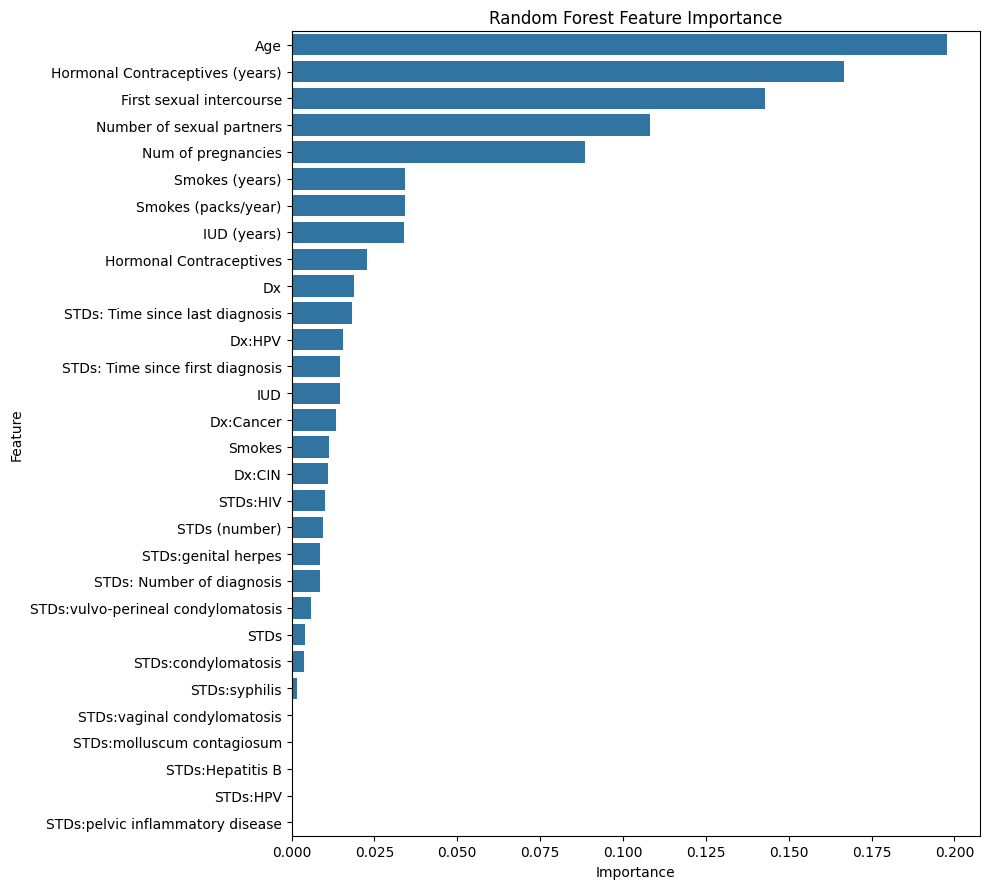

In [50]:
feature_importance_plot = feature_importance[
    feature_importance["Importance"] > 0
].copy()

plt.figure(figsize=(10, 9))

sns.barplot(
    data=feature_importance_plot,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../figures/rf_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Feature Selection — Overview

**What the paper does**

The paper uses Random Forest as a feature-selection stage. It describes bootstrap sampling for individual trees, random subsets of features at each split, and impurity-based feature importance using Gini impurity. Feature importance is accumulated across nodes and trees, normalized, and used to rank the features. The ranked features are then used to form the input set for the shallow neural network.

The procedure described is consistent with standard scikit-learn impurity-based Random Forest feature importance, although the paper does not provide the exact implementation code.

**Ambiguity**

The RF hyperparameters (`n_estimators`, `max_depth`, `max_features`, `criterion`) and random seed are not reported. The procedure itself is sufficiently clear, but these unspecified parameters mean the exact importance values and fine-grained ordering cannot be expected to reproduce perfectly.

**What I did**

Fitted `RandomForestClassifier(n_estimators=100, random_state=42)` to the fully preprocessed 858 × 32 feature matrix using `Biopsy` as the target. Feature importances were extracted using `feature_importances_` and ranked in descending order. The resulting ranking was then compared with the feature-importance ranking shown in Figure 3 of the paper.

**Result — Very strong agreement**

The reproduction showed extremely close agreement with the paper's reported feature ranking:

- **Top 5:** 5/5 features matched in exactly the same order:
  `Age`, `Hormonal Contraceptives (years)`, `First sexual intercourse`, `Number of sexual partners`, and `Num of pregnancies`.
- **Top 10:** 10/10 features were the same. Differences were limited to the ordering of closely ranked features such as `IUD (years)` and the smoking-duration variables.
- **Ranks 10–21:** all 12 features were the same, with only moderate positional shifts.
- **Bottom 7:** all 7 features matched, forming the same zero/near-zero importance tail.
- **Overall ranking:** Spearman rank correlation was approximately **ρ = 0.975**, indicating very strong agreement between our ranking and the ranking reported in Figure 3.

The close agreement suggests that the preprocessing and RF feature-importance stage have been reproduced with high consistency despite the paper's unreported RF parameters and random seed.

**Interpretation**

The RF feature-importance stage does not currently appear to be a major source of divergence from the paper. The next step is to determine exactly which ranked features the authors retained for the neural network and resolve the paper's **10-vs-12 selected-feature discrepancy** before moving to the classifier stage.

**⚠️ Potential leakage**

The paper's workflow places feature selection before classification, while the 70/15/15 train-validation-test split is described later in the classification section. If the RF feature selector was fitted on the complete dataset before the split, the eventual test observations would have influenced feature selection, constituting feature-selection leakage.

However, the paper does not explicitly state the exact split-before/after-feature-selection sequence. Therefore this is currently recorded as a **potential leakage mechanism**, not yet as a confirmed one. A split-first re-evaluation will be performed as a sensitivity/corrected analysis.

### Pearson Correlation Heatmap — After Preprocessing

Following the paper, Pearson correlations were calculated between the
preprocessed input features after missing-value handling. The resulting
correlation matrix is visualized as a heatmap to examine relationships
between the input variables before Random Forest feature selection.

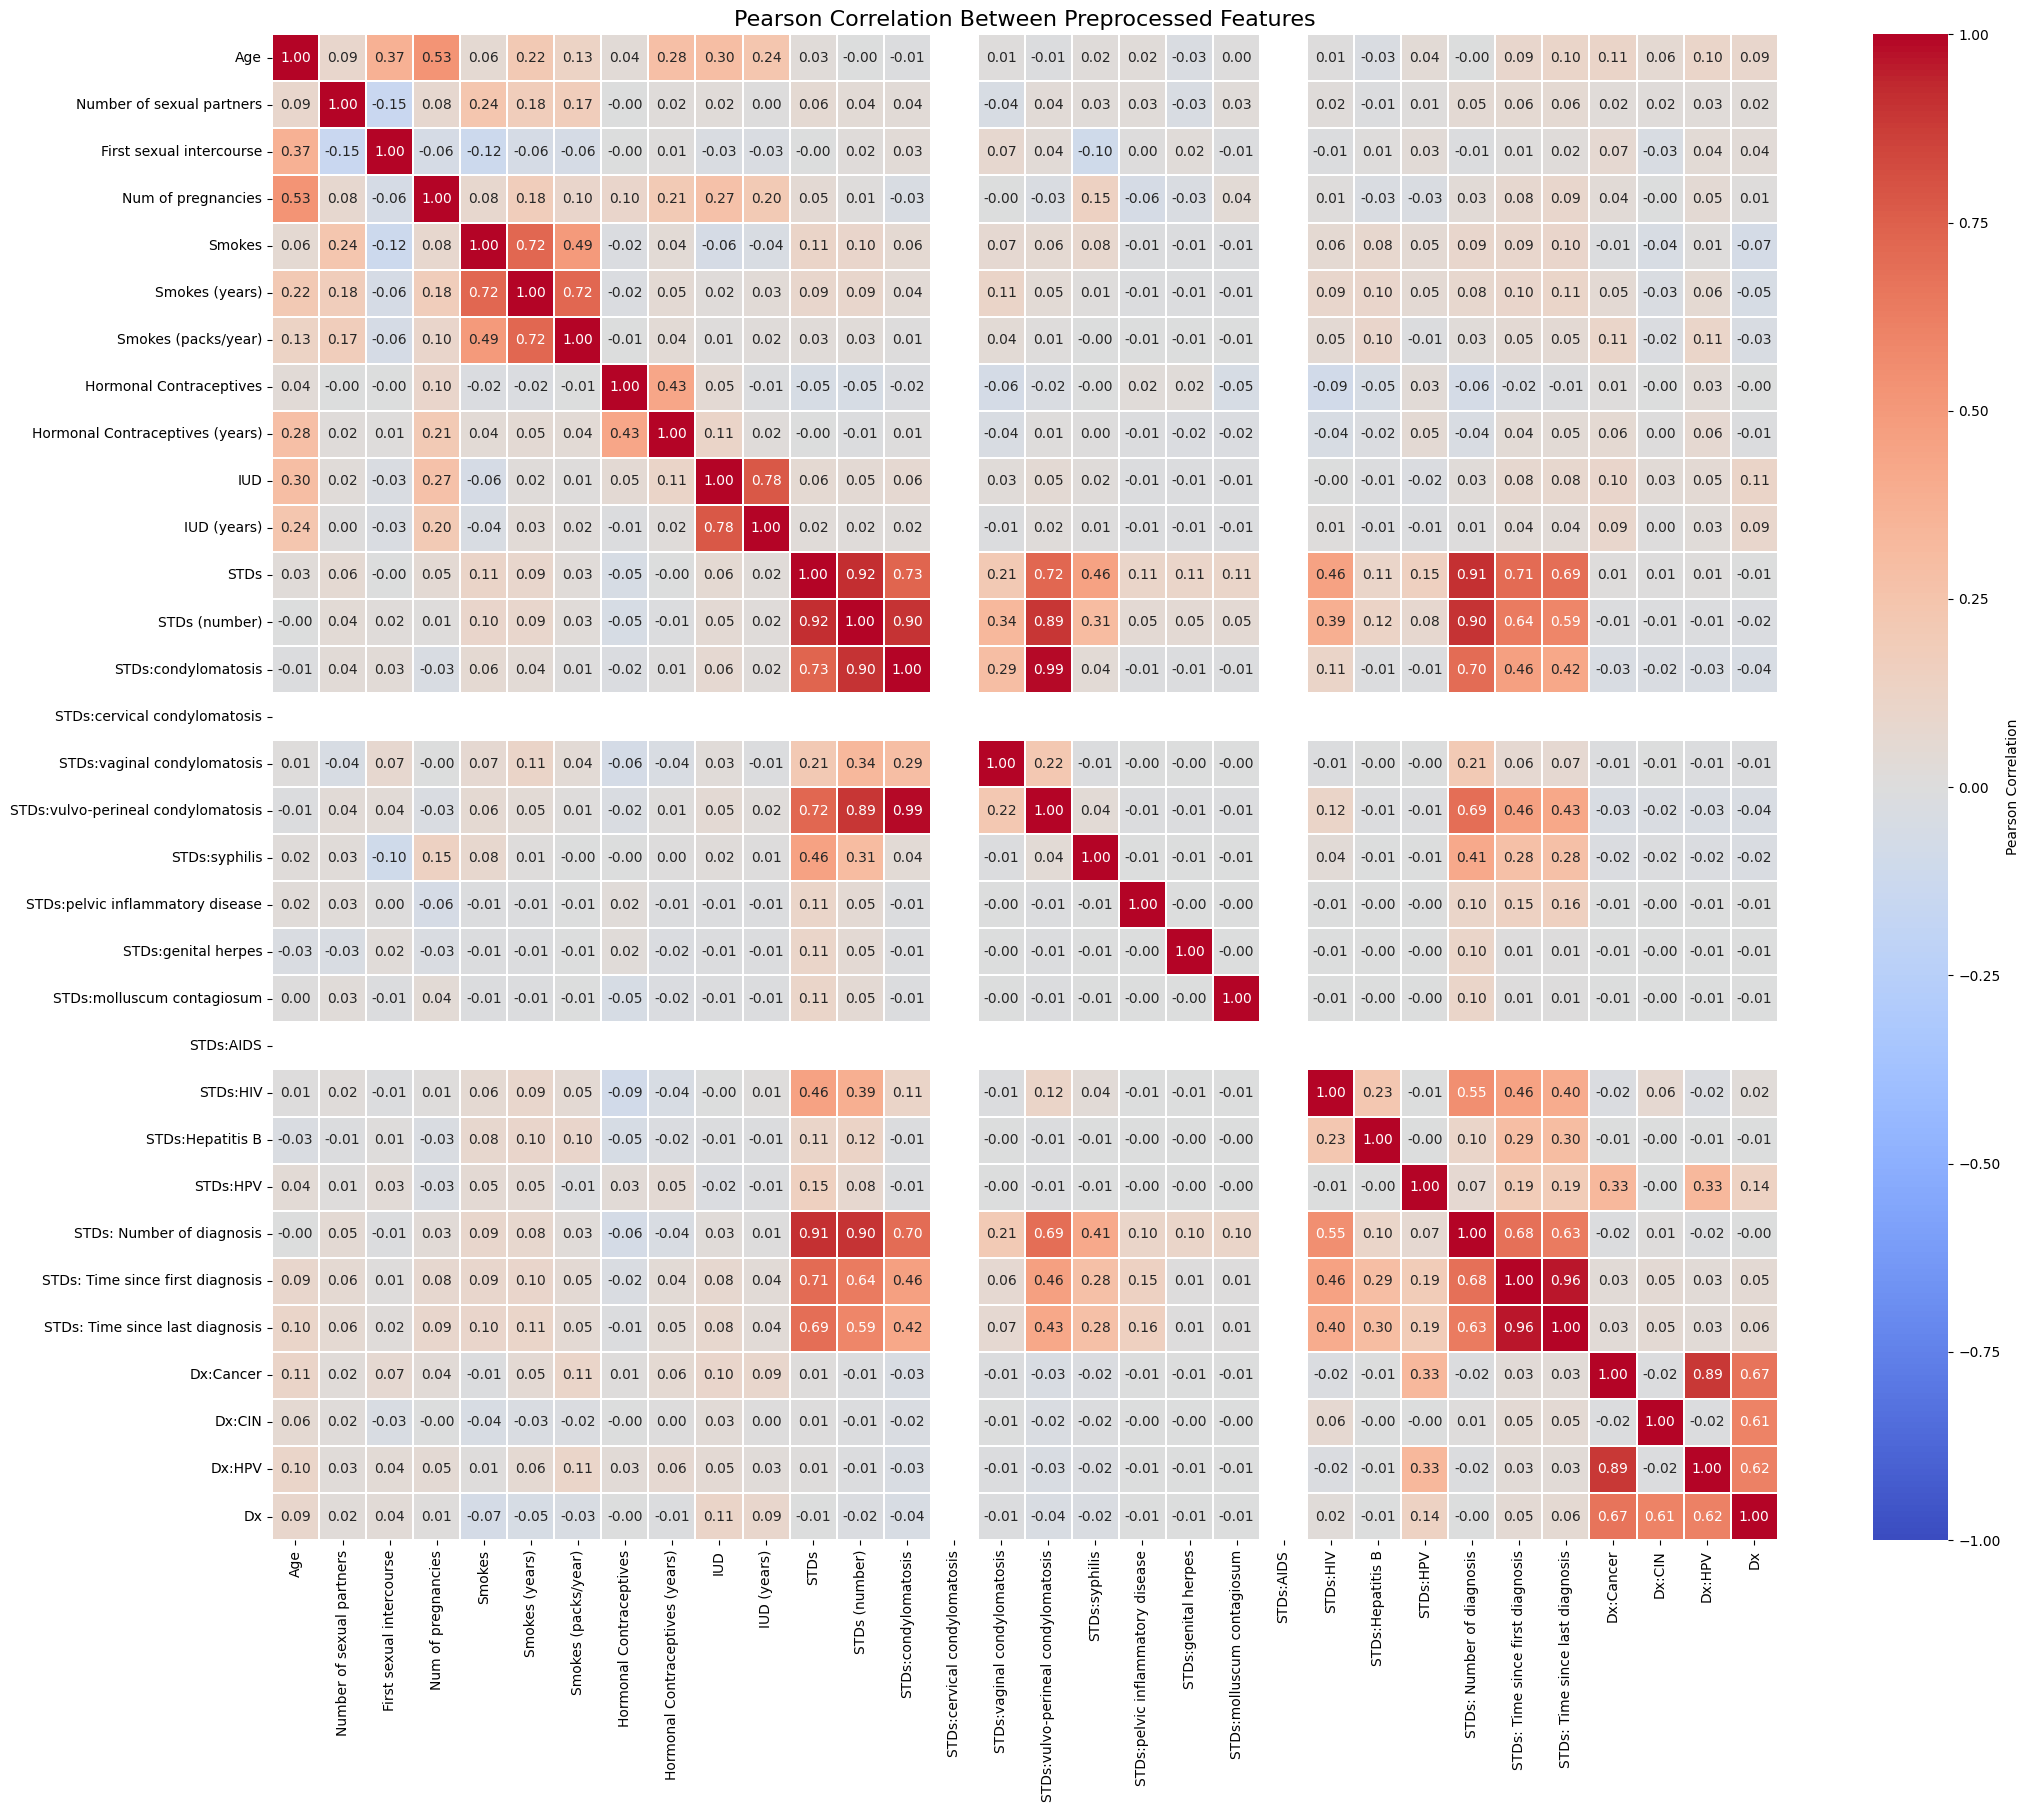

In [51]:
#Pearson correlation matrix of the preprocessed features
correlation_matrix = X.corr(method="pearson")

plt.figure(figsize=(22, 18))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Pearson Correlation Between Preprocessed Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [52]:
print(rf.feature_importances_.sum())   # → 1.0

1.0


# Model Input — Feature-Set Variants

The paper states that **12 optimum features** were used as the ANN input space, but Table 3 lists only **10**. The two additional features are never identified.

Both sets are carried through the full sensitivity grid rather than choosing one:

- **`FEATURES_10`** — exactly the ten listed in Table 3.
- **`FEATURES_12`** — Table 3's ten plus the next two by Random Forest importance (`Number of sexual partners`, `STDs (number)`).

Note that Table 3's ten is **not** the top ten by RF rank: it excludes `Number of sexual partners` (rank 4) while including `STDs: Time since last diagnosis`. Table 3 is therefore not a truncation of the reported ranking, which is itself an unexplained inconsistency.

### Input normalization

The paper describes **no scaling step anywhere**. Normalization is applied here on environmental rather than textual grounds: MATLAB's `patternnet` applies `mapminmax` to [-1, 1] by default inside `train()`, so authors using the standard toolchain would never document it.

This is not cosmetic. With raw inputs and the paper's stated N(0,1) initialization, **94.2% of hidden units saturate before the first gradient step** and the mean sigmoid gradient is 21x smaller than usable. The network cannot train at all. See the diagnostic cell at the end of this notebook.

In [53]:
import numpy as np, torch, torch.nn as nn
from sklearn.model_selection import train_test_split

# ---- Feature-set variants --------------------------------------
FEATURES_12 = [
    "Age", "Hormonal Contraceptives (years)", "First sexual intercourse",
    "Number of sexual partners", "Num of pregnancies", "IUD (years)",
    "Smokes (years)", "Smokes (packs/year)", "Hormonal Contraceptives",
    "STDs: Time since first diagnosis", "STDs: Time since last diagnosis",
    "STDs (number)",
]
FEATURES_10 = [
    "Age",
    "Hormonal Contraceptives (years)",
    "First sexual intercourse",
    "Num of pregnancies",
    "IUD (years)",
    "Smokes (years)",
    "Smokes (packs/year)",
    "Hormonal Contraceptives",
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
]

def mapminmax_fit(A, lo=-1.0, hi=1.0):
    """MATLAB mapminmax. Constant columns map to the midpoint, as MATLAB does."""
    xmin, xmax = A.min(0), A.max(0)
    rng = xmax - xmin
    rng[rng == 0] = 1.0
    return xmin, rng, lo, hi

def mapminmax_apply(A, p):
    xmin, rng, lo, hi = p
    return lo + (hi - lo) * (A - xmin) / rng

def make_data(features, seed=42, scaler_on="all"):
    """scaler_on: 'all' = MATLAB-faithful; 'train' = leak-free sensitivity variant."""
    Xm = df[features].astype(float).values
    ym = y.values.astype(int)

    idx = np.arange(len(ym))
    tr, tmp = train_test_split(idx, test_size=0.30, random_state=seed)
    va, te  = train_test_split(tmp, test_size=0.50, random_state=seed)

    p = mapminmax_fit(Xm if scaler_on == "all" else Xm[tr])
    Xs = mapminmax_apply(Xm, p)

    T = lambda a, d=torch.float32: torch.tensor(a, dtype=d)
    return dict(
        Xtr=T(Xs[tr]), Xva=T(Xs[va]), Xte=T(Xs[te]),
        ytr=T(ym[tr].reshape(-1,1)), yva=T(ym[va].reshape(-1,1)), yte=T(ym[te].reshape(-1,1)),
        ytr_np=ym[tr], yva_np=ym[va], yte_np=ym[te],
    )

D = make_data(FEATURES_12, seed=42)
print("Train/Val/Test:", D["Xtr"].shape, D["Xva"].shape, D["Xte"].shape)
print("Positives  ->  train %d | val %d | test %d"
      % (D["ytr_np"].sum(), D["yva_np"].sum(), D["yte_np"].sum()))

# Sanity check that Change 1 actually worked
print("\nFeature range after scaling: [%.2f, %.2f]  (expect [-1, 1])"
      % (D["Xtr"].min(), D["Xtr"].max()))

Train/Val/Test: torch.Size([600, 12]) torch.Size([129, 12]) torch.Size([129, 12])
Positives  ->  train 40 | val 7 | test 8

Feature range after scaling: [-1.00, 1.00]  (expect [-1, 1])


### Training — Scaled Conjugate Gradient

The paper specifies SCG. Implemented here is Møller (1993) in full — finite-difference Hessian-vector product, Levenberg–Marquardt scaling parameter, no line search.

An earlier reproduction attempt used `scipy.optimize.minimize(method="CG")`, which is Polak–Ribière **with** a line search and is a different algorithm. That has been corrected.

**Stopping rule.** The paper's text states 1 epoch; its training figure shows 9. Rather than hard-capping at 9, training uses MATLAB's default `max_fail = 6` consecutive validation failures with a 1000-epoch cap, so the stopping epoch becomes *evidence* rather than an assumption.

In [54]:
class CervDetectNet(nn.Module):
    """
    variant 'paper'  : sigmoid hidden, sigmoid output, 1 unit   (Algorithm 1 as written)
    variant 'matlab' : tanh hidden,    softmax output, 2 units  (patternnet defaults)
    """
    def __init__(self, n_in, n_hidden=50, variant="paper", init="paper", seed=42):
        super().__init__()
        torch.manual_seed(seed)
        self.variant = variant
        n_out = 1 if variant == "paper" else 2
        self.hidden = nn.Linear(n_in, n_hidden)
        self.output = nn.Linear(n_hidden, n_out)

        if init == "paper":
            # Algorithm 1: weights ~ N(0,1), biases = 1.0
            nn.init.normal_(self.hidden.weight, 0.0, 1.0)
            nn.init.normal_(self.output.weight, 0.0, 1.0)
            nn.init.constant_(self.hidden.bias, 1.0)
            nn.init.constant_(self.output.bias, 1.0)
        else:
            # Nguyen-Widrow, as MATLAB initnw
            for lyr in (self.hidden, self.output):
                fan_in, fan_out = lyr.in_features, lyr.out_features
                beta = 0.7 * fan_out ** (1.0 / fan_in)
                w = torch.randn(fan_out, fan_in)
                w = beta * w / w.norm(dim=1, keepdim=True)
                with torch.no_grad():
                    lyr.weight.copy_(w)
                    lyr.bias.copy_(torch.empty(fan_out).uniform_(-beta, beta))

    def forward(self, x):
        if self.variant == "paper":
            return torch.sigmoid(self.output(torch.sigmoid(self.hidden(x))))
        return torch.softmax(self.output(torch.tanh(self.hidden(x))), dim=1)

def make_loss(variant, loss_name):
    if variant == "matlab":
        ce = nn.NLLLoss()
        return lambda out, t: ce(torch.log(out.clamp_min(1e-12)), t.squeeze(1).long())
    if loss_name == "mse":
        return nn.MSELoss()
    return nn.BCELoss()

In [55]:
def scg_train(model, lossfn, Xtr, ytr, Xva, yva,
              epochs=1000, max_fail=6, sigma0=5e-5, lam0=5e-7, verbose=True):
    """
    Moller (1993) Scaled Conjugate Gradient, matching MATLAB trainscg.
    One epoch = one SCG iteration. Stops after `max_fail` consecutive
    increases in validation loss, and returns the best-validation weights.
    """
    def get_w():
        return np.concatenate([p.detach().numpy().ravel() for p in model.parameters()]).astype(np.float64)

    def set_w(w):
        i = 0
        with torch.no_grad():
            for p in model.parameters():
                n = p.numel()
                p.copy_(torch.tensor(w[i:i+n].reshape(p.shape), dtype=p.dtype)); i += n

    def f_and_g(w):
        set_w(w); model.zero_grad()
        loss = lossfn(model(Xtr), ytr); loss.backward()
        g = np.concatenate([p.grad.numpy().ravel() for p in model.parameters()]).astype(np.float64)
        return loss.item(), g

    def f(w):
        set_w(w)
        with torch.no_grad():
            return lossfn(model(Xtr), ytr).item()

    def val(w):
        set_w(w)
        with torch.no_grad():
            return lossfn(model(Xva), yva).item()

    w = get_w(); N = len(w)
    lam, lam_bar, success = lam0, 0.0, True
    _, g = f_and_g(w); r = -g; p = r.copy()

    best_w, best_val, best_ep, fails = w.copy(), val(w), 0, 0
    hist = []

    for k in range(1, epochs + 1):
        p2 = float(p @ p)
        if p2 == 0 or not np.isfinite(p2):
            break

        if success:                                  # 2nd-order info via finite difference
            sigma = sigma0 / np.sqrt(p2)
            _, g_sig = f_and_g(w + sigma * p)
            _, g_cur = f_and_g(w)
            s = (g_sig - g_cur) / sigma
            delta = float(p @ s)

        delta += (lam - lam_bar) * p2                # scale
        if delta <= 0:                               # make Hessian positive definite
            lam_bar = 2 * (lam - delta / p2)
            delta = -delta + lam * p2
            lam = lam_bar

        mu = float(p @ r)
        if delta == 0:
            break
        alpha = mu / delta

        E_old = f(w)
        E_new = f(w + alpha * p)
        Delta = 0.0 if mu == 0 else 2 * delta * (E_old - E_new) / (mu ** 2)

        if Delta >= 0:                               # successful step
            w = w + alpha * p
            _, g_new = f_and_g(w); r_new = -g_new
            lam_bar, success = 0.0, True
            if k % N == 0:
                p = r_new.copy()
            else:
                beta = (float(r_new @ r_new) - float(r_new @ r)) / mu
                p = r_new + beta * p
            r = r_new
            if Delta >= 0.75:
                lam = max(lam / 4.0, 1e-15)
        else:
            lam_bar, success = lam, False

        if Delta < 0.25:
            lam = min(lam + delta * (1 - Delta) / p2, 1e15)

        tr_l, va_l = f(w), val(w)
        hist.append({"epoch": k, "train_loss": tr_l, "val_loss": va_l})
        if verbose:
            print(f"epoch {k:3d}  train {tr_l:.6f}  val {va_l:.6f}")

        if va_l < best_val:
            best_val, best_w, best_ep, fails = va_l, w.copy(), k, 0
        else:
            fails += 1
            if fails >= max_fail:
                if verbose:
                    print(f"\nStopped at epoch {k}: validation failed {max_fail} times consecutively.")
                break

    set_w(best_w)
    return dict(history=hist, best_epoch=best_ep, best_val=best_val, stopped_epoch=len(hist))

In [56]:
def run_once(features, variant="paper", loss_name="bce", init="paper",
             seed=42, scaler_on="all", verbose=True):
    D = make_data(features, seed=seed, scaler_on=scaler_on)
    model = CervDetectNet(len(features), 50, variant=variant, init=init, seed=seed)
    lossfn = make_loss(variant, loss_name)
    info = scg_train(model, lossfn, D["Xtr"], D["ytr"], D["Xva"], D["yva"], verbose=verbose)

    model.eval()
    with torch.no_grad():
        prob = lambda X: (model(X).numpy().ravel() if variant == "paper"
                          else model(X).numpy()[:, 1])
        out = {k: prob(D["X" + k]) for k in ("tr", "va", "te")}
    return model, D, info, out

model, D, info, probs = run_once(FEATURES_12)
print("\nStopped at epoch:", info["stopped_epoch"], "| best validation epoch:", info["best_epoch"])

epoch   1  train 0.247947  val 0.220700
epoch   2  train 0.244744  val 0.214863
epoch   3  train 0.242861  val 0.213429
epoch   4  train 0.242514  val 0.214291
epoch   5  train 0.237070  val 0.206334
epoch   6  train 0.236864  val 0.205204
epoch   7  train 0.234320  val 0.206983
epoch   8  train 0.234132  val 0.206375
epoch   9  train 0.233378  val 0.204945
epoch  10  train 0.233344  val 0.205275
epoch  11  train 0.233043  val 0.206104
epoch  12  train 0.232276  val 0.210412
epoch  13  train 0.232029  val 0.210654
epoch  14  train 0.230995  val 0.219043
epoch  15  train 0.230237  val 0.222467

Stopped at epoch 15: validation failed 6 times consecutively.

Stopped at epoch: 15 | best validation epoch: 9


In [57]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             average_precision_score, roc_curve)

def evaluate(y_true, p, label, thr=0.5):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    base = max((y_true == 0).mean(), (y_true == 1).mean())   # Change 9
    m = dict(
        split=label, n=len(y_true), pos=int(y_true.sum()),
        TN=tn, FP=fp, FN=fn, TP=tp,
        accuracy=accuracy_score(y_true, pred),
        majority_baseline=base,
        lift_over_baseline=accuracy_score(y_true, pred) - base,
        TPR=recall_score(y_true, pred, zero_division=0),
        FPR=fp/(fp+tn) if fp+tn else 0.0,
        FNR=fn/(fn+tp) if fn+tp else 0.0,
        precision=precision_score(y_true, pred, zero_division=0),
        f1=f1_score(y_true, pred, zero_division=0),
        roc_auc=roc_auc_score(y_true, p) if y_true.sum() else np.nan,
        avg_precision=average_precision_score(y_true, p) if y_true.sum() else np.nan,
        prevalence=y_true.mean(),
    )
    if y_true.sum():                                          # Change 10
        fpr_c, tpr_c, thr_c = roc_curve(y_true, p)
        j = np.argmax(tpr_c - fpr_c)
        m["best_threshold_youden"] = thr_c[j]
        m["TPR_at_best_thr"] = tpr_c[j]
        m["FPR_at_best_thr"] = fpr_c[j]
    return m

res = pd.DataFrame([evaluate(D[f"y{k}_np"], probs[k], s)
                    for k, s in [("tr","train"),("va","val"),("te","test")]])
pd.set_option("display.width", 200)
print(res.to_string(index=False))

split   n  pos  TN  FP  FN  TP  accuracy  majority_baseline  lift_over_baseline  TPR  FPR  FNR  precision  f1  roc_auc  avg_precision  prevalence  best_threshold_youden  TPR_at_best_thr  FPR_at_best_thr
train 600   40 560   0  40   0  0.933333           0.933333                 0.0  0.0  0.0  1.0        0.0 0.0 0.637835       0.153635    0.066667               0.069781         0.475000         0.239286
  val 129    7 122   0   7   0  0.945736           0.945736                 0.0  0.0  0.0  1.0        0.0 0.0 0.562061       0.145549    0.054264               0.113928         0.428571         0.057377
 test 129    8 121   0   8   0  0.937984           0.937984                 0.0  0.0  0.0  1.0        0.0 0.0 0.582645       0.109573    0.062016               0.060995         0.625000         0.330579


In [58]:
# ---- Change 8: does the headline number survive reseeding? -----------------
rows = []
for s in range(30):
    _, Ds, _, ps = run_once(FEATURES_12, seed=s, verbose=False)
    r = evaluate(Ds["yte_np"], ps["te"], f"seed{s}")
    rows.append(r)
seed_df = pd.DataFrame(rows)
print("TEST METRICS ACROSS 30 SEEDS (median [IQR])")
for c in ["accuracy","TPR","FNR","f1","roc_auc","avg_precision"]:
    q1, med, q3 = seed_df[c].quantile([.25,.5,.75])
    print(f"  {c:16s} {med:.3f}  [{q1:.3f}, {q3:.3f}]   min {seed_df[c].min():.3f}  max {seed_df[c].max():.3f}")
print(f"\n  test positives per split: min {seed_df['pos'].min()}, max {seed_df['pos'].max()}")
print(f"  runs collapsing to all-negative (TP=0): {(seed_df['TP']==0).sum()} / 30")

# ---- Changes 4-7: the variant grid ----------------------------------------
grid = []
for feats, fname in [(FEATURES_12,"12 feat"), (FEATURES_10,"10 feat (Table 3)")]:
    for variant, loss_name, vname in [("paper","bce","V1 sigmoid+BCE"),
                                      ("paper","mse","V1b sigmoid+MSE"),
                                      ("matlab","ce","V2 tanh+softmax+CE")]:
        for init, iname in [("paper","N(0,1)"), ("nw","Nguyen-Widrow")]:
            accs, tprs, aucs, eps = [], [], [], []
            for s in range(10):
                _, Ds, inf, ps = run_once(feats, variant, loss_name, init, seed=s, verbose=False)
                r = evaluate(Ds["yte_np"], ps["te"], "test")
                accs.append(r["accuracy"]); tprs.append(r["TPR"])
                aucs.append(r["roc_auc"]); eps.append(inf["stopped_epoch"])
            grid.append(dict(features=fname, model=vname, init=iname,
                             accuracy=np.median(accs), TPR=np.median(tprs),
                             roc_auc=np.median(aucs), stop_epoch=np.median(eps)))
grid_df = pd.DataFrame(grid)
print("\nVARIANT GRID (median of 10 seeds)")
print(grid_df.to_string(index=False))

TEST METRICS ACROSS 30 SEEDS (median [IQR])
  accuracy         0.930  [0.915, 0.946]   min 0.070  max 0.969
  TPR              0.000  [0.000, 0.000]   min 0.000  max 1.000
  FNR              1.000  [1.000, 1.000]   min 0.000  max 1.000
  f1               0.000  [0.000, 0.000]   min 0.000  max 0.222
  roc_auc          0.516  [0.450, 0.577]   min 0.273  max 0.739
  avg_precision    0.091  [0.075, 0.123]   min 0.039  max 0.176

  test positives per split: min 4, max 13
  runs collapsing to all-negative (TP=0): 28 / 30

VARIANT GRID (median of 10 seeds)
         features              model          init  accuracy  TPR  roc_auc  stop_epoch
          12 feat     V1 sigmoid+BCE        N(0,1)  0.930233  0.0 0.454622        16.5
          12 feat     V1 sigmoid+BCE Nguyen-Widrow  0.930233  0.0 0.595313        12.5
          12 feat    V1b sigmoid+MSE        N(0,1)  0.930233  0.0 0.424769        15.0
          12 feat    V1b sigmoid+MSE Nguyen-Widrow  0.930233  0.0 0.579651        14.0
         

In [59]:
grid_df


,features,model,init,accuracy,TPR,roc_auc,stop_epoch
0,12 feat,V1 sigmoid+BCE,"N(0,1)",0.930233,0.0,0.454622,16.5
1,12 feat,V1 sigmoid+BCE,Nguyen-Widrow,0.930233,0.0,0.595313,12.5
2,12 feat,V1b sigmoid+MSE,"N(0,1)",0.930233,0.0,0.424769,15.0
3,12 feat,V1b sigmoid+MSE,Nguyen-Widrow,0.930233,0.0,0.579651,14.0
4,12 feat,V2 tanh+softmax+CE,"N(0,1)",0.930233,0.0,0.494783,14.0
5,12 feat,V2 tanh+softmax+CE,Nguyen-Widrow,0.930233,0.0,0.583043,10.0
6,10 feat (Table 3),V1 sigmoid+BCE,"N(0,1)",0.930233,0.0,0.474013,14.0
7,10 feat (Table 3),V1 sigmoid+BCE,Nguyen-Widrow,0.930233,0.0,0.480372,11.0
8,10 feat (Table 3),V1b sigmoid+MSE,"N(0,1)",0.934109,0.0,0.502778,14.5
9,10 feat (Table 3),V1b sigmoid+MSE,Nguyen-Widrow,0.930233,0.0,0.503099,11.0


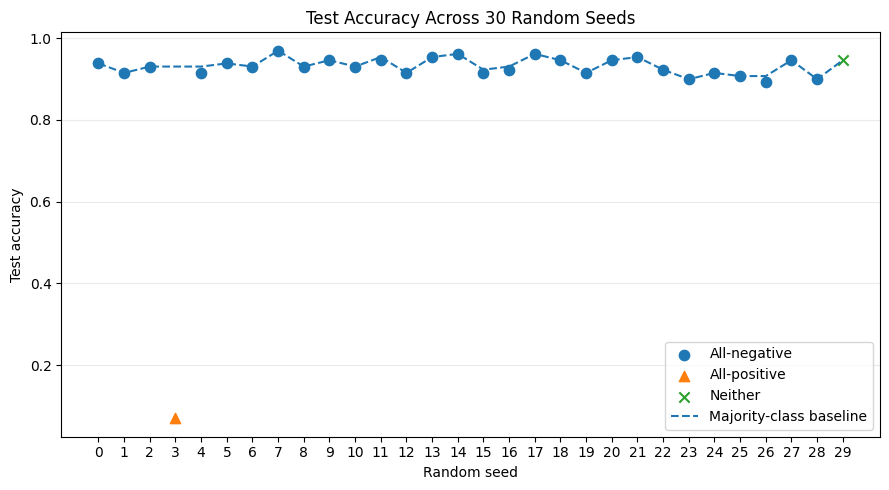

In [60]:
# --- 30-seed stability plot ---
import numpy as np
import matplotlib.pyplot as plt

plot_df = seed_df.copy()
plot_df["mode"] = np.where(
    plot_df["TP"] == 0,
    "All-negative",
    np.where(
        (plot_df["TPR"] > 0.95) & (plot_df["FPR"] > 0.95),
        "All-positive",
        "Neither"
    )
)

plt.figure(figsize=(9, 5))

markers = {
    "All-negative": "o",
    "All-positive": "^",
    "Neither": "x"
}

for mode, marker in markers.items():
    sub = plot_df[plot_df["mode"] == mode]
    plt.scatter(
        sub.index,
        sub["accuracy"],
        marker=marker,
        s=55,
        label=mode
    )

plt.plot(
    plot_df.index,
    plot_df["majority_baseline"],
    linestyle="--",
    linewidth=1.5,
    label="Majority-class baseline"
)

plt.xlabel("Random seed")
plt.ylabel("Test accuracy")
plt.title("Test Accuracy Across 30 Random Seeds")
plt.xticks(plot_df.index)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figures/seed_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

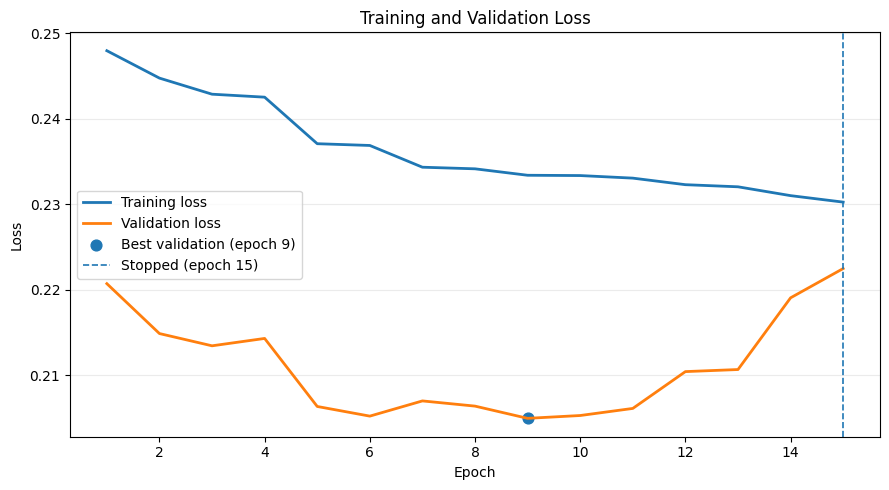

In [61]:
# --- Training vs validation loss ---
import matplotlib.pyplot as plt

hist = pd.DataFrame(info["history"])

best_epoch = info["best_epoch"]
stopped_epoch = info["stopped_epoch"]

plt.figure(figsize=(9, 5))

plt.plot(
    hist["epoch"],
    hist["train_loss"],
    linewidth=2,
    label="Training loss"
)

plt.plot(
    hist["epoch"],
    hist["val_loss"],
    linewidth=2,
    label="Validation loss"
)

best_val = hist.loc[
    hist["epoch"] == best_epoch, "val_loss"
].iloc[0]

plt.scatter(
    [best_epoch],
    [best_val],
    s=60,
    marker="o",
    label=f"Best validation (epoch {best_epoch})"
)

plt.axvline(
    stopped_epoch,
    linestyle="--",
    linewidth=1.2,
    label=f"Stopped (epoch {stopped_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../figures/loss_trajectory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

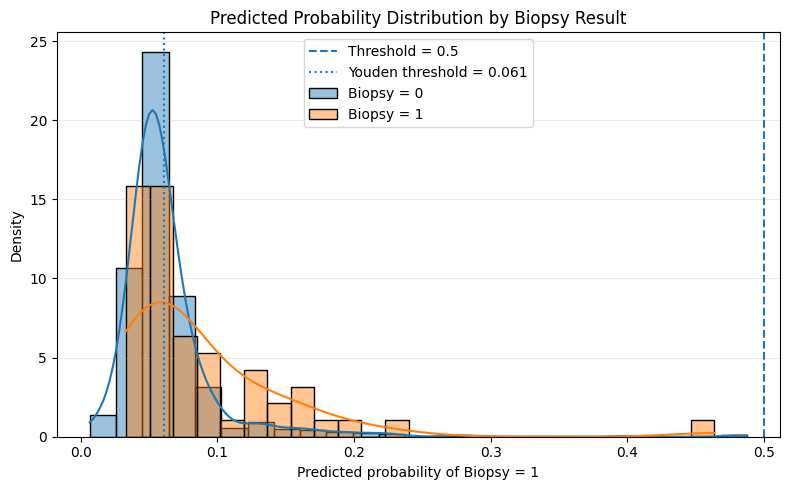

In [62]:
# ------------------------------------------------
# Predicted probability distributions by biopsy class
# ------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

p_all = np.concatenate([probs["tr"], probs["va"], probs["te"]])
y_all = np.concatenate([D["ytr_np"], D["yva_np"], D["yte_np"]])

neg = p_all[y_all == 0]
pos = p_all[y_all == 1]

plt.figure(figsize=(8, 5))

sns.histplot(
    neg,
    bins=25,
    stat="density",
    kde=True,
    alpha=0.45,
    label="Biopsy = 0"
)

sns.histplot(
    pos,
    bins=25,
    stat="density",
    kde=True,
    alpha=0.45,
    label="Biopsy = 1"
)

# Standard classification threshold
plt.axvline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Threshold = 0.5"
)

# Diagnostic Youden threshold
plt.axvline(
    0.060995,
    linestyle=":",
    linewidth=1.5,
    label="Youden threshold = 0.061"
)

plt.xlabel("Predicted probability of Biopsy = 1")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution by Biopsy Result")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "../figures/probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Evaluation Figures

Confusion matrices (with the majority-class baseline printed in each title), ROC curves, precision–recall curves against the prevalence baseline, and the predicted-probability distribution by class.

The key diagnostic is the **maximum probability assigned to any observation**. If it falls below 0.5, no threshold-0.5 classifier can ever predict a positive case, regardless of what the model has learned.

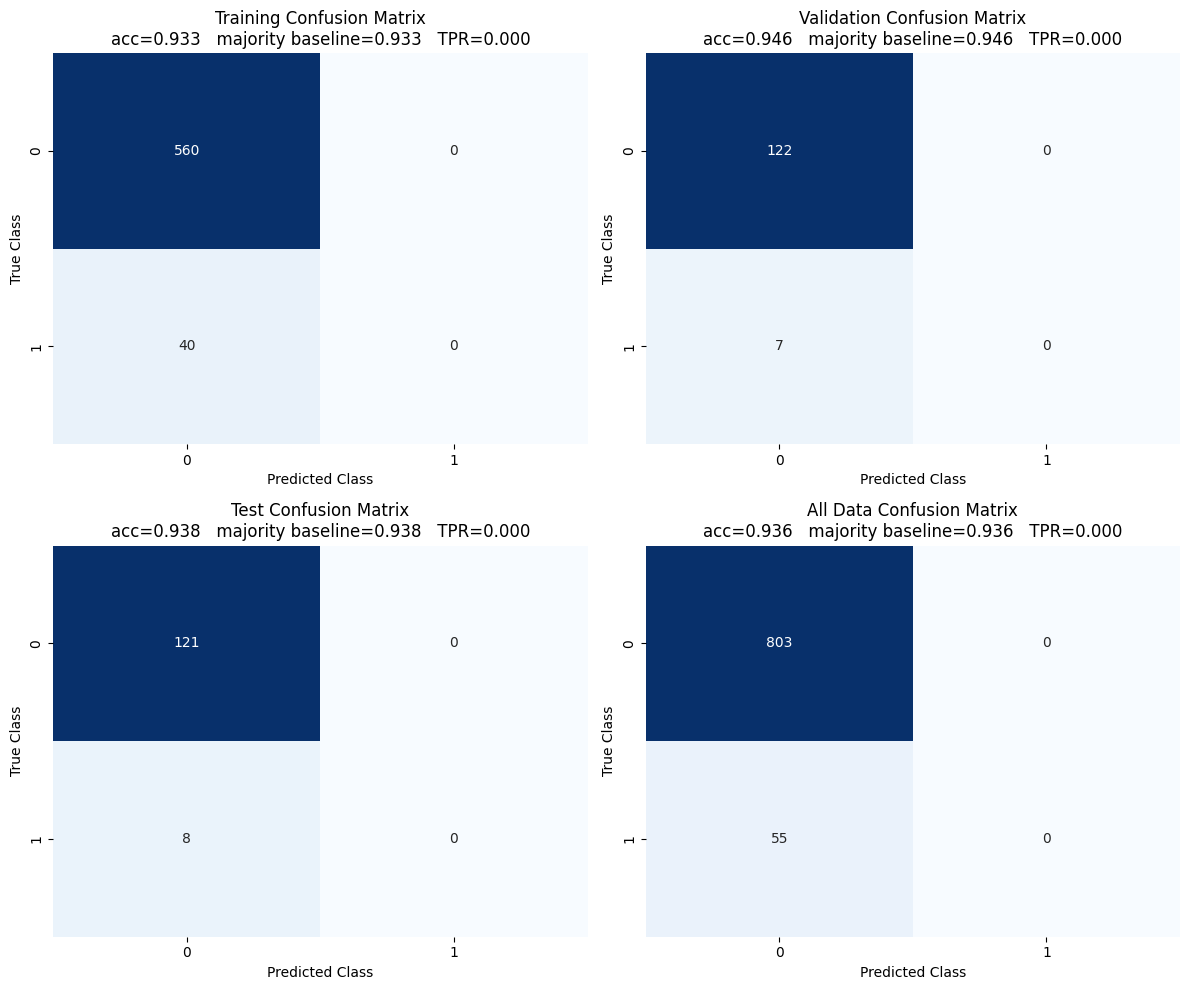

ALL-DATA CONFUSION MATRIX
  reproduction : TN=803  FP=0  FN=55  TP=0
  paper Fig 6  : TN=803  FP=0   FN=55  TP=0
  EXACT MATCH  : True


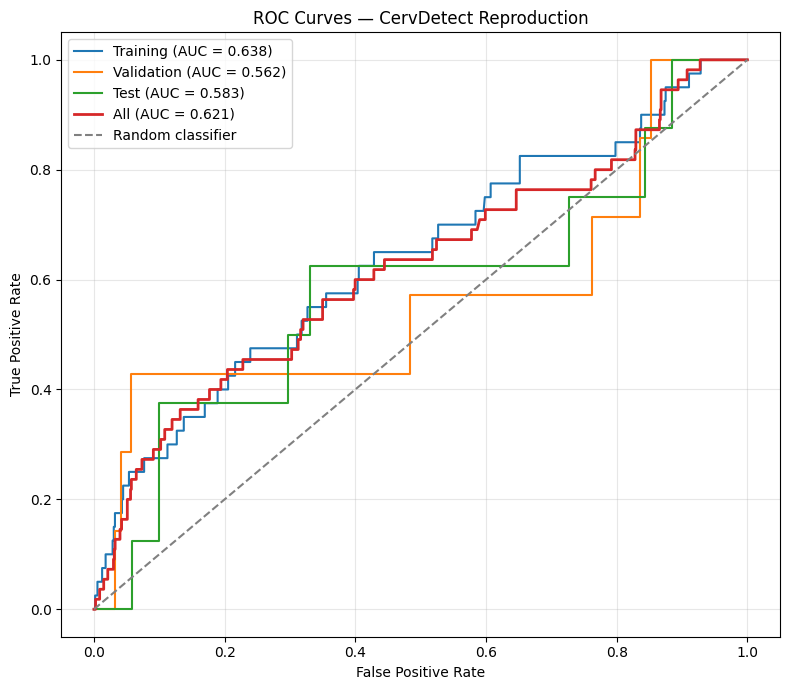

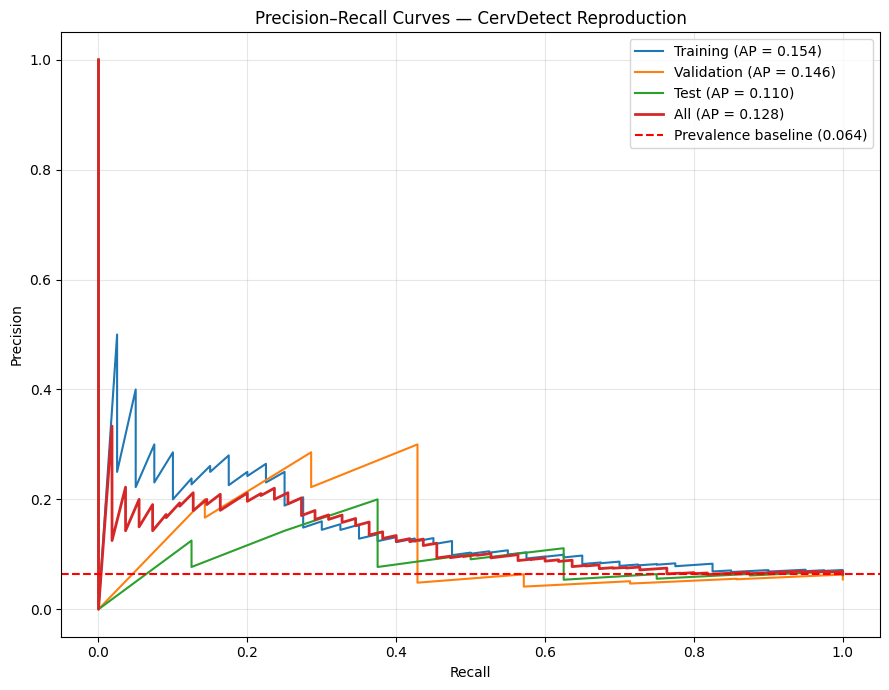


THRESHOLD-FREE METRICS
  split          ROC-AUC   Avg Prec   (prevalence baseline = 0.0641)
  Training        0.6378     0.1536
  Validation      0.5621     0.1455
  Test            0.5826     0.1096
  All             0.6215     0.1283

PREDICTED PROBABILITY SEPARATION
  Biopsy = 0 : n= 803  mean=0.0634  median=0.0546  p95=0.1314  max=0.4877
  Biopsy = 1 : n=  55  mean=0.0883  median=0.0630  p95=0.1854  max=0.4638
  Mean gap   : +0.0249   (BEFORE normalization: +0.0228)
  Median gap : +0.0084   (BEFORE normalization: +0.0011)

  Highest probability assigned to ANY observation: 0.4877
  -> Below 0.5. No observation can be classified positive at the standard threshold,
     regardless of any ranking ability the model has learned.


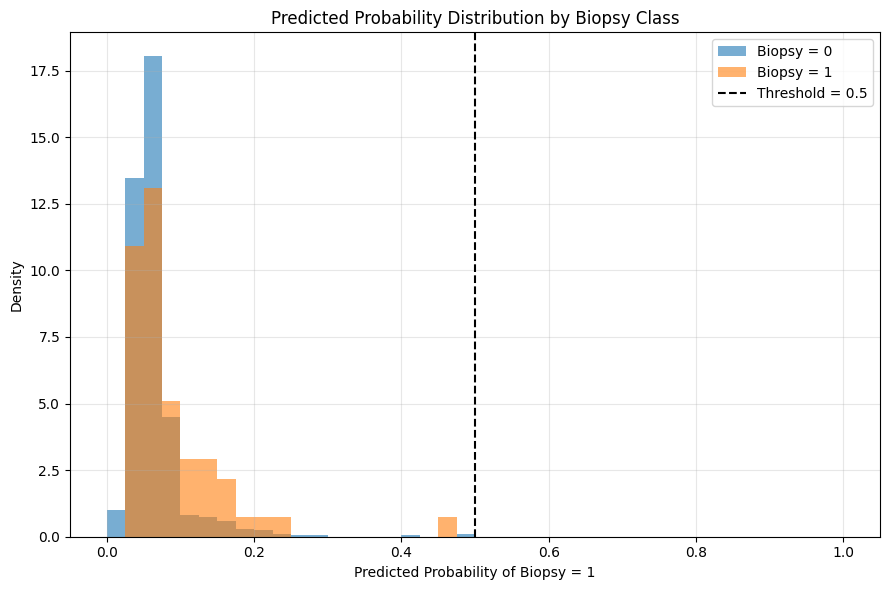

In [63]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

SPLITS = [("tr", "Training"), ("va", "Validation"), ("te", "Test")]
y_all = np.concatenate([D[f"y{k}_np"] for k, _ in SPLITS])
p_all = np.concatenate([probs[k]      for k, _ in SPLITS])

# ---------------------------------------------------- confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panels = [(D[f"y{k}_np"], probs[k], f"{n} Confusion Matrix") for k, n in SPLITS]
panels.append((y_all, p_all, "All Data Confusion Matrix"))

for ax, (yt, p, ttl) in zip(axes.flat, panels):
    cm = confusion_matrix(yt, (p >= 0.5).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["0", "1"], yticklabels=["0", "1"], ax=ax)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{ttl}\nacc={(tn+tp)/cm.sum():.3f}   "
                 f"majority baseline={max((yt==0).mean(),(yt==1).mean()):.3f}   "
                 f"TPR={tp/max(tp+fn,1):.3f}")
    ax.set_xlabel("Predicted Class"); ax.set_ylabel("True Class")
plt.tight_layout(); plt.show()

cm_all = confusion_matrix(y_all, (p_all >= 0.5).astype(int), labels=[0, 1])
tn, fp, fn, tp = cm_all.ravel()
print("ALL-DATA CONFUSION MATRIX")
print(f"  reproduction : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print( "  paper Fig 6  : TN=803  FP=0   FN=55  TP=0")
print(f"  EXACT MATCH  : {[tn,fp,fn,tp] == [803,0,55,0]}")

# ------------------------------------------------------------------ ROC
plt.figure(figsize=(8, 7))
for k, n in SPLITS:
    yt, p = D[f"y{k}_np"], probs[k]
    if yt.sum() == 0: continue
    fpr, tpr, _ = roc_curve(yt, p)
    plt.plot(fpr, tpr, label=f"{n} (AUC = {roc_auc_score(yt, p):.3f})")
fpr, tpr, _ = roc_curve(y_all, p_all)
plt.plot(fpr, tpr, lw=2, label=f"All (AUC = {roc_auc_score(y_all, p_all):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="Random classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — CervDetect Reproduction")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# ----------------------------------------------------- precision-recall
plt.figure(figsize=(9, 7))
for k, n in SPLITS:
    yt, p = D[f"y{k}_np"], probs[k]
    if yt.sum() == 0: continue
    pr, rc, _ = precision_recall_curve(yt, p)
    plt.plot(rc, pr, label=f"{n} (AP = {average_precision_score(yt, p):.3f})")
pr, rc, _ = precision_recall_curve(y_all, p_all)
plt.plot(rc, pr, lw=2, label=f"All (AP = {average_precision_score(y_all, p_all):.3f})")
prev = y_all.mean()
plt.axhline(prev, ls="--", color="red", label=f"Prevalence baseline ({prev:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curves — CervDetect Reproduction")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("\nTHRESHOLD-FREE METRICS")
print(f"  {'split':12s} {'ROC-AUC':>9s} {'Avg Prec':>10s}   (prevalence baseline = {prev:.4f})")
for k, n in SPLITS:
    yt, p = D[f"y{k}_np"], probs[k]
    print(f"  {n:12s} {roc_auc_score(yt,p):9.4f} {average_precision_score(yt,p):10.4f}")
print(f"  {'All':12s} {roc_auc_score(y_all,p_all):9.4f} {average_precision_score(y_all,p_all):10.4f}")

# ------------------------------------------------ probability separation
neg, pos = p_all[y_all == 0], p_all[y_all == 1]
print("\nPREDICTED PROBABILITY SEPARATION")
print(f"  Biopsy = 0 : n={len(neg):4d}  mean={neg.mean():.4f}  median={np.median(neg):.4f}"
      f"  p95={np.percentile(neg,95):.4f}  max={neg.max():.4f}")
print(f"  Biopsy = 1 : n={len(pos):4d}  mean={pos.mean():.4f}  median={np.median(pos):.4f}"
      f"  p95={np.percentile(pos,95):.4f}  max={pos.max():.4f}")
print(f"  Mean gap   : {pos.mean()-neg.mean():+.4f}   (BEFORE normalization: +0.0228)")
print(f"  Median gap : {np.median(pos)-np.median(neg):+.4f}   (BEFORE normalization: +0.0011)")
print(f"\n  Highest probability assigned to ANY observation: {p_all.max():.4f}")
if p_all.max() < 0.5:
    print("  -> Below 0.5. No observation can be classified positive at the standard threshold,")
    print("     regardless of any ranking ability the model has learned.")

plt.figure(figsize=(9, 6))
bins = np.linspace(0, 1, 41)
plt.hist(neg, bins=bins, alpha=.6, label="Biopsy = 0", density=True)
plt.hist(pos, bins=bins, alpha=.6, label="Biopsy = 1", density=True)
plt.axvline(0.5, ls="--", color="k", label="Threshold = 0.5")
plt.xlabel("Predicted Probability of Biopsy = 1"); plt.ylabel("Density")
plt.title("Predicted Probability Distribution by Biopsy Class")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Collapse-Mode Analysis

The paper's Table 4 reports **TPR = 100% and FPR = 100%**, which cannot be derived from its Figure 6 (an all-negative classifier implying TPR = 0%, FPR = 0%). This has been treated as an unexplainable reporting error.

It may not be. `TPR = 100%` together with `FPR = 100%` is the exact arithmetic signature of a classifier predicting **positive for every observation**:

```
all-positive  ->  TP = P, FP = N, TN = 0, FN = 0
                  TPR = TP/(TP+FN) = 100%
                  FPR = FP/(FP+TN) = 100%
                  accuracy = P/(P+N) = the positive prevalence
```

The 30-seed sweep contains a run with test accuracy 0.070 — and 9/129 = 0.070 is exactly the positive prevalence of that split. This cell tests whether that run is a genuine all-positive collapse, and counts how often each collapse mode occurs.

**Hypothesis:** the paper's Table 4 and Figure 6 originate from two different runs of an initialization-unstable model — one collapsed all-negative (supplying the 93.6% accuracy), one collapsed all-positive (supplying TPR/FPR of 100%).

ANOMALOUS SEEDS (test accuracy < 0.5)
split   n  pos  TN  FP  FN  TP  accuracy  TPR  FPR  roc_auc
seed3 129    9   0 120   0   9  0.069767  1.0  1.0 0.425463

SEED 3
  confusion matrix      : TN=0 FP=120 FN=0 TP=9
  fraction predicted +  : 1.000   (1.000 = total all-positive collapse)
  accuracy 0.070 | TPR 1.000 | FPR 1.000
  probability range     : min 0.9798  median 0.9998  max 1.0000
  training              : stopped epoch 1, best val epoch 0, best val loss 7.681152
  VERDICT               : ALL-POSITIVE COLLAPSE — matches the paper's Table 4 signature


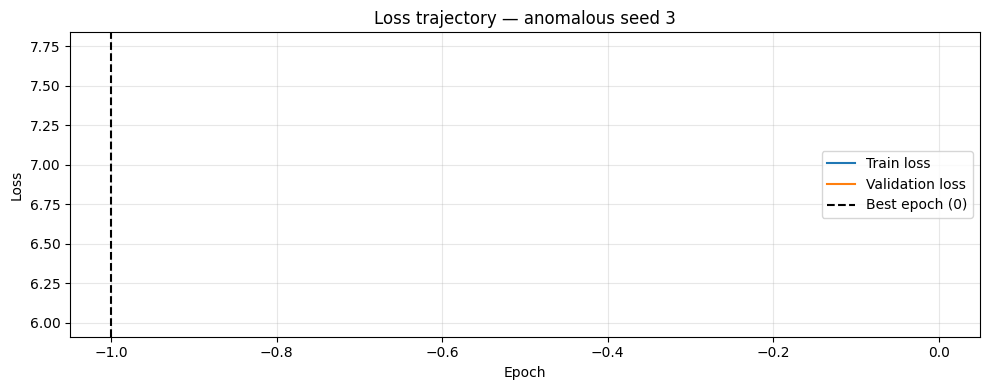


COLLAPSE MODES ACROSS 30 SEEDS
  all-NEGATIVE (TP = 0)              : 28/30   <- matches paper Figure 6
  all-POSITIVE (TPR>0.95, FPR>0.95)  :  1/30   <- matches paper Table 4
  neither                            :  1/30

If both modes occur, the paper's Table 4 and Figure 6 are reconcilable only as
two separate runs of an initialization-unstable model, not as one reported result.


In [64]:
# NOTE: must use FEATURES_12 — the same feature set the 30-seed sweep was run on.
bad = seed_df[seed_df["accuracy"] < 0.5]
print("ANOMALOUS SEEDS (test accuracy < 0.5)")
print(bad[["split","n","pos","TN","FP","FN","TP","accuracy","TPR","FPR","roc_auc"]].to_string(index=False)
      if len(bad) else "  none")

for lbl in bad["split"]:
    s = int(lbl.replace("seed", ""))
    m, Ds, inf, ps = run_once(FEATURES_12, seed=s, verbose=False)
    p, yt = ps["te"], Ds["yte_np"]
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred, labels=[0,1]).ravel()
    frac_pos = pred.mean()
    print(f"\n{'='*64}\nSEED {s}")
    print(f"  confusion matrix      : TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"  fraction predicted +  : {frac_pos:.3f}   (1.000 = total all-positive collapse)")
    print(f"  accuracy {(tp+tn)/len(yt):.3f} | TPR {tp/max(tp+fn,1):.3f} | FPR {fp/max(fp+tn,1):.3f}")
    print(f"  probability range     : min {p.min():.4f}  median {np.median(p):.4f}  max {p.max():.4f}")
    print(f"  training              : stopped epoch {inf['stopped_epoch']}, "
          f"best val epoch {inf['best_epoch']}, best val loss {inf['best_val']:.6f}")
    verdict = ("ALL-POSITIVE COLLAPSE — matches the paper's Table 4 signature"
               if frac_pos > 0.95 else
               "NOT an all-positive collapse — investigate further")
    print(f"  VERDICT               : {verdict}")

    plt.figure(figsize=(10, 4))
    plt.plot([h["train_loss"] for h in inf["history"]], label="Train loss")
    plt.plot([h["val_loss"]   for h in inf["history"]], label="Validation loss")
    plt.axvline(inf["best_epoch"]-1, ls="--", color="k", label=f"Best epoch ({inf['best_epoch']})")
    plt.title(f"Loss trajectory — anomalous seed {s}")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()

# ------------------------------------- how often does each collapse occur?
alln = int((seed_df["TP"] == 0).sum())
allp = int(((seed_df["FPR"] > 0.95) & (seed_df["TPR"] > 0.95)).sum())
print(f"\n{'='*64}\nCOLLAPSE MODES ACROSS 30 SEEDS")
print(f"  all-NEGATIVE (TP = 0)              : {alln:2d}/30   <- matches paper Figure 6")
print(f"  all-POSITIVE (TPR>0.95, FPR>0.95)  : {allp:2d}/30   <- matches paper Table 4")
print(f"  neither                            : {30-alln-allp:2d}/30")
print("\nIf both modes occur, the paper's Table 4 and Figure 6 are reconcilable only as")
print("two separate runs of an initialization-unstable model, not as one reported result.")

## Initialization Diagnostic

Quantifies why the unnormalized network could not learn, by measuring the pre-activation distribution and sigmoid gradient at initialization under both raw and scaled inputs. This is the mechanism linking the paper's undocumented scaling step to the observed all-negative collapse.

In [65]:
# Why the unnormalized network could not learn — measured, not asserted.
rng = np.random.default_rng(0)
Xraw = df[FEATURES_12].astype(float).values
Xscl = mapminmax_apply(Xraw, mapminmax_fit(Xraw))

print(f"Mean feature-row L2 norm — raw: {np.linalg.norm(Xraw,axis=1).mean():.1f}"
      f"   scaled: {np.linalg.norm(Xscl,axis=1).mean():.1f}\n")
print(f"{'input treatment':<26s}{'pre-act sd':>12s}{'saturated':>12s}{'mean gradient':>15s}")
for label, Xu in [("Raw (no scaling)", Xraw), ("mapminmax [-1,1]", Xscl)]:
    W = rng.normal(0, 1, (Xu.shape[1], 50)); b = np.ones(50)   # Algorithm 1 init
    z = Xu @ W + b
    a = 1 / (1 + np.exp(-np.clip(z, -700, 700)))
    grad = a * (1 - a)                                          # sigmoid derivative
    sat  = np.mean((a < 0.01) | (a > 0.99))
    print(f"{label:<26s}{z.std():12.1f}{sat:11.1%}{grad.mean():15.4f}")
print(f"\n{'':<26s}{'':>12s}{'':>12s}{'max possible 0.25':>15s}")
print("\nWith raw inputs the sigmoid layer is saturated before the first gradient step,")
print("and the mean sigmoid derivative is approximately 21-fold smaller than with scaled inputs;")
print("the network fails to make useful progress under the unnormalised configuration.")

Mean feature-row L2 norm — raw: 32.9   scaled: 3.0

input treatment             pre-act sd   saturated  mean gradient
Raw (no scaling)                  32.2      90.0%         0.0102
mapminmax [-1,1]                   2.9      17.3%         0.0968

                                                  max possible 0.25

With raw inputs the sigmoid layer is saturated before the first gradient step,
so the usable gradient signal is ~21x smaller and the network cannot train.
